# Context Matters: FIT5230 Milestone 3

**Light.Ningyizhuo_No.1 | Yan Zhiheng and He Hongjie | Theme 3, Light side**

This notebook evaluates two distinct defenses. Yan tests whether weak phonetic context improves mouth-dynamics detection. He audits the periodic colour trace introduced by Dark.Mimic's rPPG evasion. The public pilot runs end to end on CPU. Peer videos remain private, so the notebook includes their hashes, aggregate results and a guarded rerun path without redistributing the MP4 files.

## 1. Reproducible source and environment

The notebook contains a readable source snapshot and verifies its SHA256 before execution. A fresh run downloads approximately 180 MB of public models and videos. No paid GPU is required.

In [1]:
from pathlib import Path
import hashlib, json, os, subprocess, sys
SOURCES = {'artifacts/m3_results/attack_vs_neutral.csv': 'roi,channel,peak_hz_attack,peak_to_median_ratio_attack,target_band_energy_fraction_attack,peak_hz_neutral,peak_to_median_ratio_neutral,target_band_energy_fraction_neutral,peak_to_median_ratio_ratio,target_band_energy_fraction_ratio\nglobal,red,1.1589403973509935,1070.884740008738,0.9456918104760784,0.8278145695364238,9.82642603354429,0.2043617083266858,108.98008455496213,4.627539171694177\nglobal,green,1.1589403973509935,929.925130574967,0.9388008421856344,1.6556291390728477,8.65354478933382,0.1107587540702676,107.46175737383061,8.47608706026108\nglobal,blue,1.1589403973509935,127.52218868690676,0.6602763128284589,2.06953642384106,17.97638923621195,0.0039781535791344,7.093871133476785,165.97557125286434\nforehead,red,1.2417218543046358,489.84849247327145,0.9104207109443644,1.1589403973509935,6.631279890403184,0.1738970980817813,73.86937372107943,5.235399100887852\nforehead,green,1.1589403973509935,542.2143474844129,0.9206651013692754,1.076158940397351,6.652459012143464,0.0852039760999285,81.50585317318746,10.805424154026634\nforehead,blue,1.1589403973509935,45.692672989091534,0.5265337022522436,1.076158940397351,7.662563113112352,0.0749772012195369,5.96310559725129,7.022584114743458\nleft_cheek,red,1.2417218543046358,287.7558623219458,0.8788850952946089,0.7450331125827815,10.732335031017044,0.1442193728217765,26.81204616612465,6.094084852114272\nleft_cheek,green,1.1589403973509935,587.6721675241587,0.9296119275003044,1.1589403973509935,4.809328969789299,0.1638658904144445,122.19421279262272,5.673004462058326\nleft_cheek,blue,1.1589403973509935,53.68356564299313,0.5954718744684178,1.3245033112582782,9.568555786990895,0.1116302790087989,5.610414657975825,5.334322190679838\nright_cheek,red,1.2417218543046358,602.1744841926601,0.9448672952320902,0.7450331125827815,19.27179341117975,0.0531639643729984,31.246416529316516,17.77270198668596\nright_cheek,green,1.1589403973509935,614.9569486170733,0.9401711570566496,1.903973509933775,3.6402431161660584,0.0613969229164872,168.93293359613637,15.31300124495622\nright_cheek,blue,1.1589403973509935,39.81686482713067,0.5451432492833928,2.06953642384106,3.349336069156955,0.0207020958947572,11.887987351819485,26.33275645397093\n', 'artifacts/m3_results/chromatic_pair_report.json': '{\n  "scope": "one Dark.Mimic pair plus one neutral re-encode control",\n  "classification": "not performed",\n  "main_observation": {\n    "red": {\n      "attack_peak_hz": 1.1589403973509935,\n      "attack_target_energy_fraction": 0.9456918104760784,\n      "neutral_target_energy_fraction": 0.2043617083266858,\n      "energy_fraction_ratio": 4.627539171694177\n    },\n    "green": {\n      "attack_peak_hz": 1.1589403973509935,\n      "attack_target_energy_fraction": 0.9388008421856344,\n      "neutral_target_energy_fraction": 0.1107587540702676,\n      "energy_fraction_ratio": 8.47608706026108\n    },\n    "blue": {\n      "attack_peak_hz": 1.1589403973509935,\n      "attack_target_energy_fraction": 0.6602763128284589,\n      "neutral_target_energy_fraction": 0.0039781535791344,\n      "energy_fraction_ratio": 165.97557125286434\n    }\n  },\n  "limitations": [\n    "single source pair",\n    "rectangular image-relative ROIs are not face tracked",\n    "paired audit requires a control video",\n    "neutral control matches codec family and target bitrate, not the peer\'s exact encoder settings",\n    "periodicity is not a physiological waveform or a real/fake decision"\n  ]\n}', 'artifacts/m3_results/chromatic_robustness_report.json': '{\n  "conditions_fixed_before_analysis": [\n    "original",\n    "h264_crf35",\n    "resize_256",\n    "fps_15"\n  ],\n  "expected_frequency_hz": 1.2,\n  "scope": "one paired Dark.Mimic A=1 example; descriptive forensic audit",\n  "red_channel": [\n    {\n      "condition": "original",\n      "channel": "red",\n      "attack": 0.9456918104760784,\n      "neutral": 0.2043617083266858,\n      "attack_to_neutral_ratio": 4.627539171694177\n    },\n    {\n      "condition": "h264_crf35",\n      "channel": "red",\n      "attack": 0.3672345169718491,\n      "neutral": 0.0434662282960078,\n      "attack_to_neutral_ratio": 8.448732070124846\n    },\n    {\n      "condition": "resize_256",\n      "channel": "red",\n      "attack": 0.7997830616915408,\n      "neutral": 0.1272925039622935,\n      "attack_to_neutral_ratio": 6.283033460701284\n    },\n    {\n      "condition": "fps_15",\n      "channel": "red",\n      "attack": 0.8732771056326861,\n      "neutral": 0.0418589577497892,\n      "attack_to_neutral_ratio": 20.862370985266207\n    }\n  ],\n  "limitations": [\n    "The paired audit requires an aligned control.",\n    "This is not an rPPG estimator or a population-level detector evaluation.",\n    "Only one peer-supplied identity/pair was available."\n  ]\n}', 'artifacts/m3_results/held_out_predictions_and_failures.csv': 'clip_id,label,generator,context_free_probability,context_probability,context_free_error,context_error\nfake_hallo_00023,fake,Hallo,0.425988241210033,0.0081412267112817,True,True\nfake_live_00198,fake,LivePortrait,0.1212545562605197,0.0357702830144825,True,True\nfake_live_00462,fake,LivePortrait,0.9369642332684418,0.9937724358614084,False,False\nreal_simon,real,none,0.7717091196328509,0.8722832535867849,True,True\nreal_william,real,none,0.0296076048006528,0.0008225678181607,False,False\nreal_yorkshire,real,none,0.4154902774375774,0.1798360722792147,False,False\n', 'artifacts/m3_results/lip_report.json': '{\n  "weak_context_minus_context_free": {\n    "macro_f1": 0.0,\n    "macro_f1_bootstrap_95_ci": [\n      0.0,\n      0.0\n    ],\n    "auroc": -0.11111111111111116,\n    "auroc_bootstrap_95_ci": [\n      -0.44444444444444453,\n      0.0\n    ]\n  },\n  "bootstrap": "5000 paired stratified resamples; fixed threshold 0.5",\n  "interpretation": "No evidence that weak proxy context improves the six-clip held-out pilot.",\n  "limitations": [\n    "Only six held-out clips (three real, three fake).",\n    "Real and fake clips come from different source collections, so domain cues may confound the pilot.",\n    "Whisper word timestamps plus uniform CMUdict phone placement are weak proxies, not forced alignment.",\n    "The result is feasibility evidence, not a publication-level generalisation claim."\n  ]\n}', 'artifacts/m3_results/peer_pair_provenance.json': '{\n  "scope": "Dark.Mimic peer-supplied pair used for the M3 paired forensic audit",\n  "redistribution": "raw videos excluded from the public repository",\n  "files": [\n    {\n      "role": "control",\n      "original_name": "person01_fake01_control.mp4",\n      "sha256": "05b771eee52dc629904f9e0b40f52d715d8c42d2535576c2f135974f1d302edd"\n    },\n    {\n      "role": "Dark.Mimic A=1 modification",\n      "original_name": "person01_fake01_attacked_A1.mp4",\n      "sha256": "55cde2f07cc3f95c4f5c35f505e229d19e5f599567e434caa89fd18b8066123a"\n    },\n    {\n      "role": "team-created neutral re-encode control",\n      "original_name": "person01_fake01_control_neutral_reencode.mp4",\n      "sha256": "88024d5372605531d58241a6c8418a76aa2543e06273aaeb092ab71cddb265da"\n    }\n  ],\n  "claim_boundary": "One aligned pair supports a descriptive manipulation audit only. It does not estimate physiology or establish population-level real/fake detection."\n}\n', 'artifacts/m3_results/robustness_summary.csv': 'condition,channel,attack,neutral,attack_to_neutral_ratio\nfps_15,blue,0.3877921832479636,0.0564465025436157,6.870083455539519\nfps_15,green,0.9109519133229174,0.0303664811772365,29.998599706237627\nfps_15,red,0.8732771056326861,0.0418589577497892,20.862370985266207\nh264_crf35,blue,0.2917083675415769,0.0334865677702447,8.711205326954452\nh264_crf35,green,0.7329905046214068,0.2015880252795499,3.636081575802633\nh264_crf35,red,0.3672345169718491,0.0434662282960078,8.448732070124846\noriginal,blue,0.6602763128284589,0.0039781535791344,165.97557125286434\noriginal,green,0.9388008421856342,0.1107587540702676,8.476087060261078\noriginal,red,0.9456918104760784,0.2043617083266858,4.627539171694177\nresize_256,blue,0.1967305769054491,0.045828883363256,4.29272027743056\nresize_256,green,0.8842977536771358,0.0401267692917742,22.037601563363655\nresize_256,red,0.7997830616915408,0.1272925039622935,6.283033460701284\n', 'artifacts/m3_results/test_metrics_with_bootstrap.csv': 'model,n_test,macro_f1,macro_f1_ci_low,macro_f1_ci_high,auroc,auroc_ci_low,auroc_ci_high\ncontext_free,6,0.4857142857142857,0.14285714285714285,0.8285714285714285,0.6666666666666667,0.1083333333333343,1.0\nweak_context,6,0.4857142857142857,0.14285714285714285,0.8285714285714285,0.5555555555555556,0.0,1.0\n', 'challenge/dummy_answer_key.csv': 'clip_id,label,start_s,end_s,cue\ndummy_001,real,,,other\ndummy_002,fake,1.0,2.0,context_transition\n', 'challenge/dummy_catalog.csv': 'clip_id,duration_s\ndummy_001,4.0\ndummy_002,4.0\n', 'challenge/dummy_submission.csv': 'clip_id,prediction,fake_probability,start_s,end_s,cue,comment\ndummy_001,0,0.2,,,other,Software fixture only\ndummy_002,1,0.8,1.1,1.9,context_transition,Software fixture with partial interval overlap\n', 'challenge/submission_template.csv': 'clip_id,prediction,fake_probability,start_s,end_s,cue,comment\n', 'configs/default.json': '{\n  "seed": 5230,\n  "frame_stride": 1,\n  "smoothing_window": 5,\n  "min_coverage": 0.8,\n  "context_window_s": 0.2,\n  "decision_threshold": 0.5,\n  "min_segment_frames": 5\n}\n', 'data/m3_pilot_manifest.csv': 'clip_id,file_path,label,speaker_id,generator,transcript,central_phoneme,previous_phoneme,next_phoneme,compression,split,source_id\nfake_hallo_00023,data/processed/m3_pilot/fake_hallo_00023.mp4,fake,ffhq_00023,Hallo,unknown,unknown,unknown,unknown,standardized_h264_crf23,test,fake_hallo_00023\nfake_live_00198,data/processed/m3_pilot/fake_live_00198.mp4,fake,ffhq_00198,LivePortrait,unknown,unknown,unknown,unknown,standardized_h264_crf23,test,fake_live_00198\nfake_live_00462,data/processed/m3_pilot/fake_live_00462.mp4,fake,ffhq_00462,LivePortrait,unknown,unknown,unknown,unknown,standardized_h264_crf23,test,fake_live_00462\nreal_simon,data/processed/m3_pilot/real_simon.mp4,real,simon,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,test,real_simon\nreal_william,data/processed/m3_pilot/real_william.mp4,real,william,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,test,real_william\nreal_yorkshire,data/processed/m3_pilot/real_yorkshire.mp4,real,yorkshire_james,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,test,real_yorkshire\nfake_hallo_00054,data/processed/m3_pilot/fake_hallo_00054.mp4,fake,ffhq_00054,Hallo,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,fake_hallo_00054\nfake_hallo_00139,data/processed/m3_pilot/fake_hallo_00139.mp4,fake,ffhq_00139,Hallo,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,fake_hallo_00139\nfake_hallo_00346,data/processed/m3_pilot/fake_hallo_00346.mp4,fake,ffhq_00346,Hallo,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,fake_hallo_00346\nfake_live_01071,data/processed/m3_pilot/fake_live_01071.mp4,fake,ffhq_01071,LivePortrait,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,fake_live_01071\nfake_live_01115,data/processed/m3_pilot/fake_live_01115.mp4,fake,ffhq_01115,LivePortrait,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,fake_live_01115\nfake_live_01253,data/processed/m3_pilot/fake_live_01253.mp4,fake,ffhq_01253,LivePortrait,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,fake_live_01253\nreal_ahmad,data/processed/m3_pilot/real_ahmad.mp4,real,ahmad,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,real_ahmad\nreal_daniel,data/processed/m3_pilot/real_daniel.mp4,real,daniel,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,real_daniel\nreal_gereon,data/processed/m3_pilot/real_gereon.mp4,real,gereon,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,real_gereon\nreal_ingid,data/processed/m3_pilot/real_ingid.mp4,real,ingid,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,real_ingid\nreal_mckensie,data/processed/m3_pilot/real_mckensie.mp4,real,mckensie,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,real_mckensie\nreal_sam,data/processed/m3_pilot/real_sam.mp4,real,sam,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,train,real_sam\nfake_hallo_01896,data/processed/m3_pilot/fake_hallo_01896.mp4,fake,ffhq_01896,Hallo,unknown,unknown,unknown,unknown,standardized_h264_crf23,val,fake_hallo_01896\nfake_hallo_02235,data/processed/m3_pilot/fake_hallo_02235.mp4,fake,ffhq_02235,Hallo,unknown,unknown,unknown,unknown,standardized_h264_crf23,val,fake_hallo_02235\nfake_live_03975,data/processed/m3_pilot/fake_live_03975.mp4,fake,ffhq_03975,LivePortrait,unknown,unknown,unknown,unknown,standardized_h264_crf23,val,fake_live_03975\nreal_james,data/processed/m3_pilot/real_james.mp4,real,james,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,val,real_james\nreal_john,data/processed/m3_pilot/real_john.mp4,real,john,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,val,real_john\nreal_omar,data/processed/m3_pilot/real_omar.mp4,real,omar,none,unknown,unknown,unknown,unknown,standardized_h264_crf23,val,real_omar\n', 'data/m3_pilot_provenance.json': '[\n  {\n    "clip_id": "real_ahmad",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:Ahmad_20200617_Eng-Apc.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/6/6a/Ahmad_20200617_Eng-Apc.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "Wikitongues",\n      "credit": "<a rel=\\"nofollow\\" class=\\"external free\\" href=\\"https://www.dropbox.com/s/dw5txf0k3ts2mba/Ahmad_20200617_eng-apc.mp4?e=3&amp;dl=0\\">https://www.dropbox.com/s/dw5txf0k3ts2mba/Ahmad_20200617_eng-apc.mp4?e=3&amp;dl=0</a>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/6/6a/Ahmad_20200617_Eng-Apc.webm/Ahmad_20200617_Eng-Apc.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 418,\n        "height": 240,\n        "bandwidth": 268168\n      }\n    },\n    "raw_sha256": "e0ca069bf6a7ae870919dedff01c630dfe111d65cb0ed78302a52e66851ed663",\n    "processed_sha256": "80e4187a52d7316c45caa45138d86e583cdeb7ee9a379bb298c526c854062739",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_ahmad.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_ahmad.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_daniel",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:Daniel_speaking_English.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/8/8c/Daniel_speaking_English.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "Wikitongues, Inc",\n      "credit": "<a rel=\\"nofollow\\" class=\\"external autonumber\\" href=\\"https://wikitongues.org/videos/daniel_20250704_eng\\">[1]</a>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/8/8c/Daniel_speaking_English.webm/Daniel_speaking_English.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 136,\n        "height": 240,\n        "bandwidth": 165416\n      }\n    },\n    "raw_sha256": "986680e43f6edab17cb466c8b1a501d26a09d7f56dc63973ea3fa881bd0941f4",\n    "processed_sha256": "4cb4a3be293812bf66442465ae63dc1d64c8c3d707d1acd5f44bfdc17c9c4bd5",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_daniel.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_daniel.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_ingid",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:Ingid_20190816_Eng%2BNys.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/7/7a/Ingid_20190816_Eng%2BNys.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "Wikitongues",\n      "credit": "<a rel=\\"nofollow\\" class=\\"external free\\" href=\\"https://www.dropbox.com/s/9k709ujqd9t9g3m/Ingid_20190816_eng%2Bnys.mp4?dl=0\\">https://www.dropbox.com/s/9k709ujqd9t9g3m/Ingid_20190816_eng%2Bnys.mp4?dl=0</a>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/7/7a/Ingid_20190816_Eng%2BNys.webm/Ingid_20190816_Eng%2BNys.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 290360\n      }\n    },\n    "raw_sha256": "8abc6053c08675e902e6f9df41ce20f3ac9827ead937cb05ecd426d516de5684",\n    "processed_sha256": "2c9c55f40579cf26a1847affe3d91961e82aa48f42c02bf06e4a551894e257c0",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_ingid.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_ingid.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_gereon",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_Gereon_speaking_English.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/c/cd/WIKITONGUES-_Gereon_speaking_English.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "<a href=\\"//commons.wikimedia.org/wiki/User:Bogreudell\\" title=\\"User:Bogreudell\\">Bogreudell</a>",\n      "credit": "<span class=\\"int-own-work\\" lang=\\"en\\">Own work</span>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/c/cd/WIKITONGUES-_Gereon_speaking_English.webm/WIKITONGUES-_Gereon_speaking_English.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 114408\n      }\n    },\n    "raw_sha256": "688fb033bc41a8f787bd442d2a650782f45c9c63383ed87ee1cfbaa9247f1e64",\n    "processed_sha256": "9ab91aec55501dbd5a31ced86f5a9ea90ebfb9e71aa58f6e8e11bfeceded4c45",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_gereon.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_gereon.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_mckensie",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_Mckensie_speaking_English.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/9/94/WIKITONGUES-_Mckensie_speaking_English.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "<a href=\\"//commons.wikimedia.org/wiki/User:Bogreudell\\" title=\\"User:Bogreudell\\">Bogreudell</a>",\n      "credit": "<span class=\\"int-own-work\\" lang=\\"en\\">Own work</span>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/9/94/WIKITONGUES-_Mckensie_speaking_English.webm/WIKITONGUES-_Mckensie_speaking_English.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 209504\n      }\n    },\n    "raw_sha256": "1051b32e90cd534f76f68e7a2a16f3252173246bc7a1c92161f98289dc0adbfc",\n    "processed_sha256": "4c57ea77cbfdaae201014696cbeef73b66e1cf130eb96557dc1171cc8868bd17",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_mckensie.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_mckensie.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_sam",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_Sam_speaking_English.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/4/48/WIKITONGUES-_Sam_speaking_English.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "<a href=\\"//commons.wikimedia.org/wiki/User:Bogreudell\\" title=\\"User:Bogreudell\\">Bogreudell</a>",\n      "credit": "<span class=\\"int-own-work\\" lang=\\"en\\">Own work</span>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/4/48/WIKITONGUES-_Sam_speaking_English.webm/WIKITONGUES-_Sam_speaking_English.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 332632\n      }\n    },\n    "raw_sha256": "c714de99205eb5f8d321581009380b1b6917e37a7c9e2d2ba5e6b78fe3878736",\n    "processed_sha256": "d798c7a60a2c2530a1e3777673b1c52127995202ed57e66bf597d0295269fa3d",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_sam.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_sam.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_james",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_James_speaking_Filipino,_English,_and_Spanish.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/3/3c/WIKITONGUES-_James_speaking_Filipino%2C_English%2C_and_Spanish.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "<a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/user/WikiTongues\\">Wikitongues</a>, James Habitan",\n      "credit": "<bdi lang=\\"en\\" dir=\\"ltr\\"><a href=\\"//commons.wikimedia.org/wiki/Commons:YouTube_files\\" title=\\"Commons:YouTube files\\">YouTube</a>: <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/watch?v=fG0X7P1WFZk\\"><bdi lang=\\"\\">WIKITONGUES: James speaking Filipino, English, and Spanish</bdi></a> \\u2013 View/save archived versions on <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://web.archive.org/web/*/https://www.youtube.com/watch?v=fG0X7P1WFZk\\">archive.org</a></bdi>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/3/3c/WIKITONGUES-_James_speaking_Filipino%2C_English%2C_and_Spanish.webm/WIKITONGUES-_James_speaking_Filipino%2C_English%2C_and_Spanish.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 146992\n      }\n    },\n    "raw_sha256": "19a58d087285fde8fbdf8e9b7f46f076049a35ecf6f87d8d18c9733e0a292cf2",\n    "processed_sha256": "8e98a7673c26c4b43bf30137a2db7f583a9847f2eb1f2a713187e63b7866a0c4",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_james.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_james.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_john",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_John_speaking_English,_Spanish,_and_Greek.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/4/45/WIKITONGUES-_John_speaking_English%2C_Spanish%2C_and_Greek.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "<a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/user/WikiTongues\\">Wikitongues</a>, John Kazaklis",\n      "credit": "<bdi lang=\\"en\\" dir=\\"ltr\\"><a href=\\"//commons.wikimedia.org/wiki/Commons:YouTube_files\\" title=\\"Commons:YouTube files\\">YouTube</a>: <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/watch?v=22HBqPN8Oco\\"><bdi lang=\\"\\">WIKITONGUES: John speaking English, Spanish, and Greek</bdi></a> \\u2013 View/save archived versions on <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://web.archive.org/web/*/https://www.youtube.com/watch?v=22HBqPN8Oco\\">archive.org</a></bdi>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/4/45/WIKITONGUES-_John_speaking_English%2C_Spanish%2C_and_Greek.webm/WIKITONGUES-_John_speaking_English%2C_Spanish%2C_and_Greek.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 179512\n      }\n    },\n    "raw_sha256": "3c725e4dc73d3a96e0fd21f1b77123e8614a52d738a55ae86ae4e4e2926734be",\n    "processed_sha256": "bed647125f67df1f700df9079555c60d90a378e81d390dd66a01bec64eb8ba90",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_john.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_john.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_omar",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_Omar_Speaking_English_and_Jamaican_Patois.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/f/f8/WIKITONGUES-_Omar_Speaking_English_and_Jamaican_Patois.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY 3.0",\n      "license_url": "https://creativecommons.org/licenses/by/3.0",\n      "artist": "<a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/user/WikiTongues\\">Wikitongues</a>",\n      "credit": "<bdi lang=\\"en\\" dir=\\"ltr\\"><a href=\\"//commons.wikimedia.org/wiki/Commons:YouTube_files\\" title=\\"Commons:YouTube files\\">YouTube</a>: <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/watch?v=DmvDD9kJipE\\"><bdi lang=\\"\\">WIKITONGUES: Omar Speaking English and Jamaican Patois</bdi></a> \\u2013 View/save archived versions on <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://web.archive.org/web/*/https://www.youtube.com/watch?v=DmvDD9kJipE\\">archive.org</a></bdi>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/f/f8/WIKITONGUES-_Omar_Speaking_English_and_Jamaican_Patois.webm/WIKITONGUES-_Omar_Speaking_English_and_Jamaican_Patois.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 264312\n      }\n    },\n    "raw_sha256": "0e2b52544e8d1b3cce35dc83d2e098b1eba85290ef38f83bebd461c7a3bae809",\n    "processed_sha256": "7b6394c42ccef87b7910933197156d67e3a797972608580c1948a33054afaa90",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_omar.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_omar.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_simon",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_Simon_speaking_Cumbrian.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/9/91/WIKITONGUES-_Simon_speaking_Cumbrian.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY 3.0",\n      "license_url": "https://creativecommons.org/licenses/by/3.0",\n      "artist": "<a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/user/WikiTongues\\">Wikitongues</a>",\n      "credit": "<bdi lang=\\"en\\" dir=\\"ltr\\"><a href=\\"//commons.wikimedia.org/wiki/Commons:YouTube_files\\" title=\\"Commons:YouTube files\\">YouTube</a>: <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://www.youtube.com/watch?v=ofWA7ERRwzs\\"><bdi lang=\\"\\">WIKITONGUES: Simon speaking Cumbrian</bdi></a> \\u2013 View/save archived versions on <a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://web.archive.org/web/*/https://www.youtube.com/watch?v=ofWA7ERRwzs\\">archive.org</a></bdi>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/9/91/WIKITONGUES-_Simon_speaking_Cumbrian.webm/WIKITONGUES-_Simon_speaking_Cumbrian.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 172272\n      }\n    },\n    "raw_sha256": "e7d2ede2f264a3e117e39992af6339ffb4876792e0d45f5a3361c64206f35bfc",\n    "processed_sha256": "dfcfecced1d93d820d37b1ded1a18a167b952e085c8df1e7cb4c4d3e39dc59ed",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_simon.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_simon.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_william",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:WIKITONGUES-_William_speaking_English.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/4/4c/WIKITONGUES-_William_speaking_English.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC BY-SA 4.0",\n      "license_url": "https://creativecommons.org/licenses/by-sa/4.0",\n      "artist": "<a href=\\"//commons.wikimedia.org/wiki/User:Bogreudell\\" title=\\"User:Bogreudell\\">Bogreudell</a>",\n      "credit": "<span class=\\"int-own-work\\" lang=\\"en\\">Own work</span>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/4/4c/WIKITONGUES-_William_speaking_English.webm/WIKITONGUES-_William_speaking_English.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 426,\n        "height": 240,\n        "bandwidth": 178000\n      }\n    },\n    "raw_sha256": "8fce07f18443c92060570fa28291464de3d49c7f120cf954877ff9b62d9df0ad",\n    "processed_sha256": "0a9a0465cafd93036d3912c33ad794d6ef4773b13b740536662e297938ac127a",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_william.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_william.mp4"\n    ]\n  },\n  {\n    "clip_id": "real_yorkshire",\n    "source": "Wikimedia Commons/Wikitongues",\n    "metadata": {\n      "canonical_url": "https://commons.wikimedia.org/wiki/File:James_speaking_West_Riding_Yorkshire_English.webm",\n      "download_url": "https://upload.wikimedia.org/wikipedia/commons/1/13/James_speaking_West_Riding_Yorkshire_English.webm?utm_source=commons.wikimedia.org&utm_campaign=imageinfo&utm_content=original",\n      "license_short_name": "CC0",\n      "license_url": "http://creativecommons.org/publicdomain/zero/1.0/deed.en",\n      "artist": "Wikitongues Inc",\n      "credit": "<a rel=\\"nofollow\\" class=\\"external text\\" href=\\"https://wikitongues.org/videos/james_20231214_eng/\\">https://wikitongues.org/videos/james</a>",\n      "selected_derivative": {\n        "src": "https://upload.wikimedia.org/wikipedia/commons/transcoded/1/13/James_speaking_West_Riding_Yorkshire_English.webm/James_speaking_West_Riding_Yorkshire_English.webm.240p.vp9.webm",\n        "type": "video/webm; codecs=\\"vp9, opus\\"",\n        "transcodekey": "240p.vp9.webm",\n        "width": 136,\n        "height": 240,\n        "bandwidth": 183400\n      }\n    },\n    "raw_sha256": "8bc01e8b9feaaaa7289ca3ed49fd3dfac488f245b87ec07c9577fd562c422149",\n    "processed_sha256": "16d7b62eb960ecea0dc772a953d91ed87a6128825634fc760c3015dbd07d0537",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "5",\n      "-i",\n      "data/raw/m3_pilot/real/real_yorkshire.webm",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/real_yorkshire.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_hallo_00054",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/Hallo/train/00054--ptAdtShJa_0_1--Hallo.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "dcaebb64969411f402654c1fe6acc4920588ecfd5130ed2442cd25cb4dc0cb7a",\n    "processed_sha256": "40ed44339a46fa75446cb73d1dabd6f89c8dea56962cec91d552903c9e778f55",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_hallo_00054.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_hallo_00054.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_hallo_00139",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/Hallo/train/00139--9mDnkVUl08k_0--Hallo.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "e028f5d520dcddeea1f828841cc0b7946a9b0dbf307356bbf913325abe294d6c",\n    "processed_sha256": "ae30c6a16c05b76cbd9b09c8b984d304469119c9fad73b9f25b531de51494686",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_hallo_00139.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_hallo_00139.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_live_01071",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/LivePortrait/train/01071--7F1bODlFs2U_1--LivePortrait.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "539b17ce04e8a608e3293fd9558084620efe4207d773981103c7b5cc32052c13",\n    "processed_sha256": "7018b9375a118737e19bfeb07ed786793111b4c9d716a725eea8db3ce9350e79",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_live_01071.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_live_01071.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_live_01115",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/LivePortrait/train/01115--MYcsUTqNjNQ_0--LivePortrait.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "0240c8758139c02a6d1944f8b2943542581244ac5b48d44b650590001e4f54c4",\n    "processed_sha256": "201812378d27853b8a3e579161ba651e1951cf717c3fa4c8ae2777414e3f9f53",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_live_01115.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_live_01115.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_hallo_00346",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/Hallo/train/00346--xMjEmE1YLSU_0--Hallo.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "c2d06fb4e911f359726071358f5d78294c913e738109a53e54b41c36f265a988",\n    "processed_sha256": "257c47602f97d2a69e071bb1e882bf818fa0ccc91eab71a0ba009b04bc1435d4",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_hallo_00346.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_hallo_00346.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_live_01253",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/LivePortrait/train/01253--7F1bODlFs2U_2--LivePortrait.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "861345f0e51ef43c37271f481e88cdc42a8f6a1844dae9edd71184e5783fbc5f",\n    "processed_sha256": "3b624d4db08f24c0b26b71f01bc7d2de31a9931ddeb84e22054727a0cdb2ac86",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_live_01253.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_live_01253.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_hallo_01896",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/Hallo/val/01896--7g1ti_tjuvQ_1--Hallo.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "76b4343e3b2c2a58dfb796243523b20ed60b9b16cb2f5112d4871706920a2360",\n    "processed_sha256": "fdea05a1ad69113b3b79193d18fbb7b8715efda79f49e9145e46ebff2da9565e",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_hallo_01896.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_hallo_01896.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_live_03975",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/LivePortrait/val/03975--cMFosgxgPAs_1--LivePortrait.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "5fa0df81bf2a41aafdca007d2a240f70880ebb25dd589affe6b70261c477a763",\n    "processed_sha256": "c7e7d9fe2aee690789fd8a57d2a7a74d942ed6925f629076e453f225d96fd2ea",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_live_03975.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_live_03975.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_hallo_02235",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/Hallo/val/02235--EHMPLXVeO9c_2--Hallo.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "7d24130361fc3ab605a916643b3aac6eab05e5b1ebf14b45cc410e357e457045",\n    "processed_sha256": "4b19d6e908bb4cc47757995a6432a22262f73d61332b501bff5c7c1deaedec27",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_hallo_02235.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_hallo_02235.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_hallo_00023",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/Hallo/test/00023--7lHr2ZNlULA_4--Hallo.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "28f0e04f64de0413ceef2afe4f0a8227141b0b18315cc14e7650cf23914c0f55",\n    "processed_sha256": "15774d309c9edd4df03e6097e21b06e7485cc6c390787459156dae42c843d57f",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_hallo_00023.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_hallo_00023.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_live_00198",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/LivePortrait/test/00198--H_c_crxV9O8_0--LivePortrait.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "67f508e15d792b17a4fed87796bc4d25f3f94ca5bf6e7960fa9b03212a542231",\n    "processed_sha256": "c7cd3ffc8fe0f6af3234b6835838a4db958ac23f1b4f1920e6b24acfa79338ad",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_live_00198.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_live_00198.mp4"\n    ]\n  },\n  {\n    "clip_id": "fake_live_00462",\n    "source": "TalkingHeadBench",\n    "source_url": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/LivePortrait/test/00462--OMGBYSEJ4CU_5--LivePortrait.mp4",\n    "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n    "upstream_licenses_must_be_respected": true,\n    "raw_sha256": "faf1aee5cff3dd2c791952ec28bdc8fa2ea63dc54e996d472e7dde2697f8b3ad",\n    "processed_sha256": "27cafce94fb183578993de143f938a967b01c2b23ce30e6059684a6e20bba3aa",\n    "ffmpeg": [\n      "ffmpeg",\n      "-hide_banner",\n      "-loglevel",\n      "error",\n      "-y",\n      "-ss",\n      "0",\n      "-i",\n      "data/raw/m3_pilot/fake/fake_live_00462.mp4",\n      "-t",\n      "12",\n      "-vf",\n      "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n      "-c:v",\n      "libx264",\n      "-crf",\n      "23",\n      "-preset",\n      "veryfast",\n      "-pix_fmt",\n      "yuv420p",\n      "-ac",\n      "1",\n      "-ar",\n      "16000",\n      "-c:a",\n      "aac",\n      "-map_metadata",\n      "-1",\n      "data/processed/m3_pilot/fake_live_00462.mp4"\n    ]\n  }\n]', 'data/m3_pilot_sources.json': '{\n  "scope": "24-clip course pilot: 12 licensed public real clips and 12 TalkingHeadBench generated clips",\n  "warning": "Cross-source pilot only. It cannot establish publication-level generalization and must be followed by a controlled paired subset if time permits.",\n  "standardization": {\n    "duration_s": 12,\n    "fps": 25,\n    "canvas": "512x512",\n    "video_codec": "H.264 CRF 23",\n    "audio": "AAC mono 16 kHz"\n  },\n  "real": [\n    {"id":"real_ahmad","split":"train","speaker":"ahmad","start_s":5,"filename":"Ahmad 20200617 Eng-Apc.webm"},\n    {"id":"real_daniel","split":"train","speaker":"daniel","start_s":5,"filename":"Daniel speaking English.webm"},\n    {"id":"real_ingid","split":"train","speaker":"ingid","start_s":5,"filename":"Ingid 20190816 Eng+Nys.webm"},\n    {"id":"real_gereon","split":"train","speaker":"gereon","start_s":5,"filename":"WIKITONGUES- Gereon speaking English.webm"},\n    {"id":"real_mckensie","split":"train","speaker":"mckensie","start_s":5,"filename":"WIKITONGUES- Mckensie speaking English.webm"},\n    {"id":"real_sam","split":"train","speaker":"sam","start_s":5,"filename":"WIKITONGUES- Sam speaking English.webm"},\n    {"id":"real_james","split":"val","speaker":"james","start_s":5,"filename":"WIKITONGUES- James speaking Filipino, English, and Spanish.webm"},\n    {"id":"real_john","split":"val","speaker":"john","start_s":5,"filename":"WIKITONGUES- John speaking English, Spanish, and Greek.webm"},\n    {"id":"real_omar","split":"val","speaker":"omar","start_s":5,"filename":"WIKITONGUES- Omar Speaking English and Jamaican Patois.webm"},\n    {"id":"real_simon","split":"test","speaker":"simon","start_s":5,"filename":"WIKITONGUES- Simon speaking Cumbrian.webm"},\n    {"id":"real_william","split":"test","speaker":"william","start_s":5,"filename":"WIKITONGUES- William speaking English.webm"},\n    {"id":"real_yorkshire","split":"test","speaker":"yorkshire_james","start_s":5,"filename":"James speaking West Riding Yorkshire English.webm"}\n  ],\n  "fake": [\n    {"id":"fake_hallo_00054","split":"train","speaker":"ffhq_00054","generator":"Hallo","path":"fake/Hallo/train/00054--ptAdtShJa_0_1--Hallo.mp4"},\n    {"id":"fake_hallo_00139","split":"train","speaker":"ffhq_00139","generator":"Hallo","path":"fake/Hallo/train/00139--9mDnkVUl08k_0--Hallo.mp4"},\n    {"id":"fake_live_01071","split":"train","speaker":"ffhq_01071","generator":"LivePortrait","path":"fake/LivePortrait/train/01071--7F1bODlFs2U_1--LivePortrait.mp4"},\n    {"id":"fake_live_01115","split":"train","speaker":"ffhq_01115","generator":"LivePortrait","path":"fake/LivePortrait/train/01115--MYcsUTqNjNQ_0--LivePortrait.mp4"},\n    {"id":"fake_hallo_00346","split":"train","speaker":"ffhq_00346","generator":"Hallo","path":"fake/Hallo/train/00346--xMjEmE1YLSU_0--Hallo.mp4"},\n    {"id":"fake_live_01253","split":"train","speaker":"ffhq_01253","generator":"LivePortrait","path":"fake/LivePortrait/train/01253--7F1bODlFs2U_2--LivePortrait.mp4"},\n    {"id":"fake_hallo_01896","split":"val","speaker":"ffhq_01896","generator":"Hallo","path":"fake/Hallo/val/01896--7g1ti_tjuvQ_1--Hallo.mp4"},\n    {"id":"fake_live_03975","split":"val","speaker":"ffhq_03975","generator":"LivePortrait","path":"fake/LivePortrait/val/03975--cMFosgxgPAs_1--LivePortrait.mp4"},\n    {"id":"fake_hallo_02235","split":"val","speaker":"ffhq_02235","generator":"Hallo","path":"fake/Hallo/val/02235--EHMPLXVeO9c_2--Hallo.mp4"},\n    {"id":"fake_hallo_00023","split":"test","speaker":"ffhq_00023","generator":"Hallo","path":"fake/Hallo/test/00023--7lHr2ZNlULA_4--Hallo.mp4"},\n    {"id":"fake_live_00198","split":"test","speaker":"ffhq_00198","generator":"LivePortrait","path":"fake/LivePortrait/test/00198--H_c_crxV9O8_0--LivePortrait.mp4"},\n    {"id":"fake_live_00462","split":"test","speaker":"ffhq_00462","generator":"LivePortrait","path":"fake/LivePortrait/test/00462--OMGBYSEJ4CU_5--LivePortrait.mp4"}\n  ]\n}\n', 'data/manifest.schema.json': '{\n  "$schema": "https://json-schema.org/draft/2020-12/schema",\n  "title": "S2F clip manifest record (CSV columns)",\n  "type": "object",\n  "required": ["clip_id", "file_path", "label", "speaker_id", "generator", "transcript", "central_phoneme", "previous_phoneme", "next_phoneme", "compression", "split", "source_id"],\n  "properties": {\n    "clip_id": {"type": "string", "pattern": "^[A-Za-z0-9][A-Za-z0-9_-]{0,100}$"},\n    "file_path": {"type": "string", "minLength": 1},\n    "label": {"enum": ["real", "fake"]},\n    "speaker_id": {"type": "string", "minLength": 1},\n    "generator": {"type": "string", "minLength": 1},\n    "transcript": {"type": "string", "minLength": 1},\n    "central_phoneme": {"type": "string", "minLength": 1},\n    "previous_phoneme": {"type": "string", "minLength": 1},\n    "next_phoneme": {"type": "string", "minLength": 1},\n    "compression": {"type": "string", "minLength": 1},\n    "split": {"enum": ["train", "val", "test"]},\n    "source_id": {"type": "string", "minLength": 1},\n    "evidence_type": {"type": "string"}\n  },\n  "additionalProperties": true,\n  "$comment": "Schema describes records; Python CSV validator additionally checks paths, duplicate hashes, source-family and protocol-specific speaker/generator leakage."\n}\n', 'requirements.txt': 'numpy>=1.26,<3\npandas>=2.2,<4\nscipy>=1.12,<2\nscikit-learn>=1.4,<2\nmatplotlib>=3.8,<4\nopencv-contrib-python>=4.11,<6\nmediapipe>=0.10.30,<2\njoblib>=1.3,<2\nimageio-ffmpeg>=0.6,<1\nnbformat>=5.10,<6\nnbclient>=0.10,<1\nipykernel>=6.29,<8\npytest>=8,<10\nopenai-whisper==20250625\ncmudict>=1.1,<2\n', 'scripts/audit_m3_pilot.py': '"""Create basic metadata QC and a middle-frame contact sheet for the M3 pilot."""\nfrom pathlib import Path\nimport json\nimport os\nimport subprocess\n\nos.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/.mplcache").resolve()))\nimport cv2\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n\nROOT = Path(__file__).resolve().parents[1]\nMANIFEST = ROOT / "data" / "m3_pilot_manifest.csv"\nOUT = ROOT / "outputs" / "m3_work" / "pilot_qc"\n\n\ndef has_audio(path):\n    command = [\n        "ffprobe", "-v", "error", "-select_streams", "a:0",\n        "-show_entries", "stream=codec_name", "-of", "json", str(path),\n    ]\n    result = subprocess.run(command, capture_output=True, text=True, check=True)\n    return bool(json.loads(result.stdout).get("streams"))\n\n\ndef main():\n    OUT.mkdir(parents=True, exist_ok=True)\n    manifest = pd.read_csv(MANIFEST, keep_default_na=False)\n    records, images = [], []\n    for row in manifest.itertuples():\n        path = ROOT / row.file_path\n        capture = cv2.VideoCapture(str(path))\n        if not capture.isOpened():\n            raise ValueError(f"Cannot open {path}")\n        fps = float(capture.get(cv2.CAP_PROP_FPS))\n        frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))\n        width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))\n        height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))\n        capture.set(cv2.CAP_PROP_POS_FRAMES, max(0, frames // 2))\n        ok, frame = capture.read()\n        capture.release()\n        if not ok:\n            raise ValueError(f"Cannot read middle frame from {path}")\n        images.append((row.clip_id, row.label, row.split, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))\n        records.append({\n            "clip_id": row.clip_id,\n            "label": row.label,\n            "split": row.split,\n            "fps": fps,\n            "frames": frames,\n            "duration_s": frames / fps,\n            "width": width,\n            "height": height,\n            "has_audio": has_audio(path),\n            "bytes": path.stat().st_size,\n        })\n    qc = pd.DataFrame(records)\n    qc.to_csv(OUT / "metadata_qc.csv", index=False)\n    fig, axes = plt.subplots(6, 4, figsize=(12, 16))\n    for ax, (clip_id, label, split, image) in zip(axes.ravel(), images):\n        ax.imshow(image)\n        ax.set_title(f"{clip_id}\\n{label} / {split}", fontsize=8)\n        ax.axis("off")\n    fig.suptitle("M3 24-clip pilot: middle-frame visual audit", fontsize=15)\n    fig.tight_layout(rect=(0, 0, 1, 0.98))\n    fig.savefig(OUT / "contact_sheet.png", dpi=170)\n    plt.close(fig)\n    print(qc.groupby(["split", "label"])[["duration_s", "has_audio"]].agg(["count", "mean"]))\n    print("contact sheet", (OUT / "contact_sheet.png").relative_to(ROOT))\n\n\nif __name__ == "__main__":\n    main()\n', 'scripts/build_weak_phoneme_intervals.py': '"""Create a reproducible *weak* phoneme-context pilot annotation.\n\nWhisper supplies word timestamps. CMUdict supplies an English pronunciation for\neach recognised word. Phones are placed uniformly inside a word, so these are\nnot forced-alignment ground truth. The script deliberately records that\nlimitation in every row and keeps the raw ASR output for audit.\n\nFor the small course pilot we use broad articulatory classes as the categorical\ncontext. Exact ARPAbet phones are retained as extra audit columns.\n"""\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport re\nfrom pathlib import Path\n\nimport cmudict\nimport pandas as pd\nimport whisper\n\n\nROOT = Path(__file__).resolve().parents[1]\nWORD_RE = re.compile(r"[A-Za-z\']+")\nVOWELS = {"AA", "AE", "AH", "AO", "AW", "AY", "EH", "ER", "EY", "IH", "IY", "OW", "OY", "UH", "UW"}\nSTOPS = {"P", "B", "T", "D", "K", "G"}\nFRICATIVES = {"F", "V", "TH", "DH", "S", "Z", "SH", "ZH", "HH"}\nAFFRICATES = {"CH", "JH"}\nNASALS = {"M", "N", "NG"}\nLIQUIDS = {"L", "R"}\nGLIDES = {"W", "Y"}\n\n\ndef clean_phone(phone: str) -> str:\n    return re.sub(r"\\d", "", phone.upper())\n\n\ndef phone_class(phone: str) -> str:\n    phone = clean_phone(phone)\n    for name, group in [\n        ("vowel", VOWELS),\n        ("stop", STOPS),\n        ("fricative", FRICATIVES),\n        ("affricate", AFFRICATES),\n        ("nasal", NASALS),\n        ("liquid", LIQUIDS),\n        ("glide", GLIDES),\n    ]:\n        if phone in group:\n            return name\n    return "other"\n\n\ndef normalise_word(token: str) -> str:\n    match = WORD_RE.search(token)\n    return match.group(0).lower() if match else ""\n\n\ndef flatten_words(result: dict, dictionary: dict) -> list[dict]:\n    phones = []\n    for segment in result.get("segments", []):\n        for word in segment.get("words", []):\n            token = normalise_word(word.get("word", ""))\n            if not token or token not in dictionary:\n                continue\n            start, end = float(word["start"]), float(word["end"])\n            pronunciation = dictionary[token][0]\n            if end <= start or not pronunciation:\n                continue\n            step = (end - start) / len(pronunciation)\n            for index, raw_phone in enumerate(pronunciation):\n                phones.append({\n                    "word": token,\n                    "word_start_s": start,\n                    "word_end_s": end,\n                    "word_probability": float(word.get("probability", 0.0)),\n                    "phone": clean_phone(raw_phone),\n                    "phone_start_proxy_s": start + index * step,\n                    "phone_end_proxy_s": start + (index + 1) * step,\n                })\n    return phones\n\n\ndef select_interval(phones: list[dict], duration: float) -> tuple[int, float, float]:\n    candidates = []\n    for index in range(1, len(phones) - 1):\n        item = phones[index]\n        centre = (item["phone_start_proxy_s"] + item["phone_end_proxy_s"]) / 2\n        start, end = centre - 0.10, centre + 0.10\n        if start < 0.25 or end > duration - 0.25:\n            continue\n        # Prefer a confidently recognised vowel near the middle of the clip.\n        score = item["word_probability"] - 0.04 * abs(centre - duration / 2)\n        if phone_class(item["phone"]) == "vowel":\n            score += 0.5\n        candidates.append((score, index, start, end))\n    if not candidates:\n        raise ValueError("No auditable central-phone proxy away from clip boundaries")\n    _, index, start, end = max(candidates)\n    return index, start, end\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--manifest", default="data/m3_pilot_manifest.csv")\n    parser.add_argument("--aligned-manifest", default="data/m3_pilot_aligned_manifest.csv")\n    parser.add_argument("--intervals", default="data/m3_pilot_intervals.csv")\n    parser.add_argument("--asr-dir", default="outputs/m3_work/asr")\n    parser.add_argument("--model", default="tiny.en")\n    args = parser.parse_args()\n\n    manifest_path = ROOT / args.manifest\n    manifest = pd.read_csv(manifest_path, keep_default_na=False)\n    asr_dir = ROOT / args.asr_dir\n    asr_dir.mkdir(parents=True, exist_ok=True)\n    dictionary = cmudict.dict()\n    model = whisper.load_model(args.model, download_root=str(ROOT / "models" / "whisper"))\n    intervals = []\n\n    for row in manifest.itertuples(index=False):\n        cache = asr_dir / f"{row.clip_id}.json"\n        if cache.exists():\n            result = json.loads(cache.read_text(encoding="utf-8"))\n        else:\n            print("transcribe", row.clip_id, flush=True)\n            result = model.transcribe(\n                str(ROOT / row.file_path), language="en", word_timestamps=True,\n                fp16=False, verbose=False, temperature=0,\n            )\n            cache.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")\n        phones = flatten_words(result, dictionary)\n        duration = float(max((word["end"] for segment in result.get("segments", [])\n                              for word in segment.get("words", [])), default=0.0))\n        # The video may continue after speech. Use its feature timestamp as the\n        # authoritative sampling duration so the selected context is in-bounds.\n        features = pd.read_csv(ROOT / "outputs/m3_work/pilot_features/features" / f"{row.clip_id}.csv")\n        duration = min(duration or float(features.time_s.max()), float(features.time_s.max()))\n        index, start, end = select_interval(phones, duration)\n        previous, central, following = phones[index - 1], phones[index], phones[index + 1]\n        intervals.append({\n            "clip_id": row.clip_id,\n            "start_s": round(start, 6),\n            "end_s": round(end, 6),\n            "previous_phoneme": phone_class(previous["phone"]),\n            "central_phoneme": phone_class(central["phone"]),\n            "next_phoneme": phone_class(following["phone"]),\n            "previous_phone_arpabet": previous["phone"],\n            "central_phone_arpabet": central["phone"],\n            "next_phone_arpabet": following["phone"],\n            "central_word": central["word"],\n            "word_probability": round(central["word_probability"], 6),\n            "annotation_source": "whisper_tiny.en_word_timestamp+cmudict_uniform_phone_proxy",\n            "alignment_quality": "weak_proxy_not_forced_alignment",\n        })\n        mask = manifest.clip_id.eq(row.clip_id)\n        manifest.loc[mask, "transcript"] = str(result.get("text", "")).strip()\n        manifest.loc[mask, "previous_phoneme"] = phone_class(previous["phone"])\n        manifest.loc[mask, "central_phoneme"] = phone_class(central["phone"])\n        manifest.loc[mask, "next_phoneme"] = phone_class(following["phone"])\n\n    intervals_frame = pd.DataFrame(intervals)\n    intervals_frame.to_csv(ROOT / args.intervals, index=False)\n    manifest.to_csv(ROOT / args.aligned_manifest, index=False)\n    print(intervals_frame[["previous_phoneme", "central_phoneme", "next_phoneme"]].apply(pd.Series.value_counts).fillna(0))\n    print("aligned manifest", args.aligned_manifest)\n    print("intervals", args.intervals)\n\n\nif __name__ == "__main__":\n    main()\n', 'scripts/download_m3_pilot.py': '"""Download and standardise the small M3 public pilot.\n\nRaw and processed videos are ignored by Git. The script records URLs, hashes,\nWikimedia license metadata and the exact FFmpeg command in the manifest.\n"""\nfrom pathlib import Path\nfrom urllib.parse import quote, urlencode\nfrom urllib.request import Request, urlopen\nimport hashlib\nimport json\nimport shutil\nimport subprocess\nimport sys\nimport time\nfrom urllib.error import HTTPError, URLError\n\nimport pandas as pd\n\n\nROOT = Path(__file__).resolve().parents[1]\nCONFIG = ROOT / "data" / "m3_pilot_sources.json"\nRAW = ROOT / "data" / "raw" / "m3_pilot"\nPROCESSED = ROOT / "data" / "processed" / "m3_pilot"\nMANIFEST = ROOT / "data" / "m3_pilot_manifest.csv"\nPROVENANCE = ROOT / "data" / "m3_pilot_provenance.json"\nHF_BASE = "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/"\nCOMMONS_REDIRECT = "https://commons.wikimedia.org/wiki/Special:Redirect/file/"\nCOMMONS_API = "https://commons.wikimedia.org/w/api.php"\n\n\ndef sha256(path):\n    digest = hashlib.sha256()\n    with Path(path).open("rb") as stream:\n        for chunk in iter(lambda: stream.read(1024 * 1024), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef download(url, target):\n    target = Path(target)\n    target.parent.mkdir(parents=True, exist_ok=True)\n    if target.exists() and target.stat().st_size > 0:\n        return\n    temporary = target.with_suffix(target.suffix + ".part")\n    for attempt in range(6):\n        try:\n            request = Request(url, headers={"User-Agent": "FIT5230-course-research/1.0"})\n            with urlopen(request, timeout=120) as source, temporary.open("wb") as sink:\n                shutil.copyfileobj(source, sink)\n            temporary.replace(target)\n            return\n        except (HTTPError, URLError, TimeoutError):\n            temporary.unlink(missing_ok=True)\n            if attempt == 5:\n                raise\n            time.sleep(3 * (2 ** attempt))\n\n\ndef commons_metadata(filename):\n    params = {\n        "action": "query",\n        "format": "json",\n        "prop": "videoinfo",\n        "viprop": "url|derivatives|extmetadata",\n        "titles": "File:" + filename,\n    }\n    for attempt in range(6):\n        try:\n            request = Request(COMMONS_API + "?" + urlencode(params), headers={"User-Agent": "FIT5230-course-research/1.0"})\n            with urlopen(request, timeout=60) as response:\n                payload = json.load(response)\n            break\n        except (HTTPError, URLError, TimeoutError):\n            if attempt == 5:\n                raise\n            time.sleep(3 * (2 ** attempt))\n    page = next(iter(payload["query"]["pages"].values()))\n    info = page["videoinfo"][0]\n    ext = info.get("extmetadata", {})\n    derivatives = info.get("derivatives", [])\n    preferred = next((d for d in derivatives if d.get("transcodekey") == "240p.vp9.webm"), None)\n    preferred = preferred or next((d for d in derivatives if d.get("height", 9999) <= 360), None)\n    return {\n        "canonical_url": info.get("descriptionurl"),\n        "download_url": info.get("url"),\n        "license_short_name": ext.get("LicenseShortName", {}).get("value"),\n        "license_url": ext.get("LicenseUrl", {}).get("value"),\n        "artist": ext.get("Artist", {}).get("value"),\n        "credit": ext.get("Credit", {}).get("value"),\n        "selected_derivative": preferred,\n    }\n\n\ndef transcode(source, target, start_s=0):\n    target.parent.mkdir(parents=True, exist_ok=True)\n    command = [\n        "ffmpeg", "-hide_banner", "-loglevel", "error", "-y",\n        "-ss", str(start_s), "-i", str(source), "-t", "12",\n        "-vf", "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2",\n        "-c:v", "libx264", "-crf", "23", "-preset", "veryfast", "-pix_fmt", "yuv420p",\n        "-ac", "1", "-ar", "16000", "-c:a", "aac", "-map_metadata", "-1", str(target),\n    ]\n    subprocess.run(command, check=True)\n    # Record repository-relative paths so the provenance file is portable and\n    # does not disclose the machine/user directory that produced the pilot.\n    portable = command.copy()\n    portable[portable.index(str(source))] = source.relative_to(ROOT).as_posix()\n    portable[portable.index(str(target))] = target.relative_to(ROOT).as_posix()\n    return portable\n\n\ndef main():\n    if not shutil.which("ffmpeg"):\n        raise RuntimeError("ffmpeg is required")\n    config = json.loads(CONFIG.read_text())\n    rows, provenance = [], []\n    for item in config["real"]:\n        metadata = commons_metadata(item["filename"])\n        derivative = metadata.get("selected_derivative") or {}\n        url = derivative.get("src") or metadata["download_url"] or (COMMONS_REDIRECT + quote(item["filename"]))\n        suffix = Path(url.split("?")[0]).suffix or ".webm"\n        raw = RAW / "real" / f"{item[\'id\']}{suffix}"\n        processed = PROCESSED / f"{item[\'id\']}.mp4"\n        print("real", item["id"], flush=True)\n        download(url, raw)\n        command = transcode(raw, processed, item["start_s"])\n        rows.append({\n            "clip_id": item["id"], "file_path": processed.relative_to(ROOT).as_posix(),\n            "label": "real", "speaker_id": item["speaker"], "generator": "none",\n            "transcript": "unknown", "central_phoneme": "unknown",\n            "previous_phoneme": "unknown", "next_phoneme": "unknown",\n            "compression": "standardized_h264_crf23", "split": item["split"],\n            "source_id": item["id"],\n        })\n        provenance.append({"clip_id": item["id"], "source": "Wikimedia Commons/Wikitongues",\n                           "metadata": metadata, "raw_sha256": sha256(raw),\n                           "processed_sha256": sha256(processed), "ffmpeg": command})\n    for item in config["fake"]:\n        url = HF_BASE + quote(item["path"], safe="/")\n        raw = RAW / "fake" / f"{item[\'id\']}.mp4"\n        processed = PROCESSED / f"{item[\'id\']}.mp4"\n        print("fake", item["id"], flush=True)\n        download(url, raw)\n        command = transcode(raw, processed, 0)\n        rows.append({\n            "clip_id": item["id"], "file_path": processed.relative_to(ROOT).as_posix(),\n            "label": "fake", "speaker_id": item["speaker"], "generator": item["generator"],\n            "transcript": "unknown", "central_phoneme": "unknown",\n            "previous_phoneme": "unknown", "next_phoneme": "unknown",\n            "compression": "standardized_h264_crf23", "split": item["split"],\n            "source_id": item["id"],\n        })\n        provenance.append({"clip_id": item["id"], "source": "TalkingHeadBench",\n                           "source_url": url, "dataset_card": "https://huggingface.co/datasets/luchaoqi/TalkingHeadBench",\n                           "upstream_licenses_must_be_respected": True, "raw_sha256": sha256(raw),\n                           "processed_sha256": sha256(processed), "ffmpeg": command})\n    frame = pd.DataFrame(rows).sort_values(["split", "label", "clip_id"])\n    frame.to_csv(MANIFEST, index=False)\n    PROVENANCE.write_text(json.dumps(provenance, indent=2), encoding="utf-8")\n    print(frame.groupby(["split", "label"]).size())\n    print("manifest", MANIFEST)\n\n\nif __name__ == "__main__":\n    main()\n', 'scripts/run_chromatic_robustness.py': '"""Run the paired chromatic audit under fixed post-processing conditions."""\nfrom __future__ import annotations\n\nimport json\nimport os\nfrom pathlib import Path\nimport subprocess\n\nos.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-m3")\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\nfrom s2f.chromatic import analyse_pair\n\n\nROOT = Path(__file__).resolve().parents[1]\nPRIVATE = ROOT / "data/private/dark_mimic"\nWORK = ROOT / "outputs/m3_work/chromatic_robustness"\nCONTROL = PRIVATE / "person01_fake01_control.mp4"\nATTACK = PRIVATE / "person01_fake01_attacked_A1.mp4"\nNEUTRAL = PRIVATE / "person01_fake01_control_neutral_reencode.mp4"\nCONDITIONS = {\n    "original": [],\n    "h264_crf35": ["-vf", "scale=512:448", "-r", "25", "-c:v", "libx264", "-crf", "35", "-preset", "veryfast"],\n    "resize_256": ["-vf", "scale=256:224", "-r", "25", "-c:v", "libx264", "-crf", "23", "-preset", "veryfast"],\n    "fps_15": ["-vf", "fps=15,scale=512:448", "-r", "15", "-c:v", "libx264", "-crf", "23", "-preset", "veryfast"],\n}\n\n\ndef transcode(source: Path, destination: Path, options: list[str]) -> None:\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    command = [\n        "ffmpeg", "-hide_banner", "-loglevel", "error", "-y", "-i", str(source),\n        *options, "-pix_fmt", "yuv420p", "-an", str(destination),\n    ]\n    subprocess.run(command, check=True)\n\n\ndef path_for(source: Path, condition: str, role: str) -> Path:\n    if condition == "original":\n        return source\n    destination = WORK / "videos" / condition / f"{role}.mp4"\n    transcode(source, destination, CONDITIONS[condition])\n    return destination\n\n\ndef main() -> None:\n    rows = []\n    for condition in CONDITIONS:\n        control = path_for(CONTROL, condition, "control")\n        attack = path_for(ATTACK, condition, "attack")\n        neutral = path_for(NEUTRAL, condition, "neutral")\n        for comparison, modified in [("attack", attack), ("neutral", neutral)]:\n            out = WORK / comparison / condition\n            analyse_pair(control, modified, out, expected_hz=1.2)\n            summary = pd.read_csv(out / "spectral_summary.csv")\n            global_rows = summary[summary.roi.eq("global")]\n            for record in global_rows.to_dict("records"):\n                rows.append({\n                    "condition": condition,\n                    "comparison": comparison,\n                    "channel": record["channel"],\n                    "fps": record["fps"],\n                    "n_frames": record["n"],\n                    "peak_hz": record["peak_hz"],\n                    "peak_to_median_ratio": record["peak_to_median_ratio"],\n                    "target_band_energy_fraction": record["target_band_energy_fraction"],\n                })\n\n    frame = pd.DataFrame(rows)\n    table = frame.pivot(index=["condition", "channel"], columns="comparison",\n                        values="target_band_energy_fraction").reset_index()\n    table["attack_to_neutral_ratio"] = table.attack / table.neutral\n    table.to_csv(WORK / "robustness_summary.csv", index=False)\n\n    red = table[table.channel.eq("red")].set_index("condition").loc[list(CONDITIONS)]\n    x = range(len(red))\n    fig, ax = plt.subplots(figsize=(9, 4.8))\n    ax.bar([i - 0.18 for i in x], red.attack, width=0.36, label="Dark.Mimic A=1")\n    ax.bar([i + 0.18 for i in x], red.neutral, width=0.36, label="Neutral re-encode")\n    ax.set_xticks(list(x), ["Original", "H.264 CRF 35", "256×224", "15 FPS"])\n    ax.set_ylim(0, 1)\n    ax.set_ylabel("Red-channel energy fraction near 1.2 Hz")\n    ax.set_title("Periodic chromatic trace under post-processing")\n    ax.grid(axis="y", alpha=0.2)\n    ax.legend()\n    fig.tight_layout()\n    fig.savefig(WORK / "robustness_red.png", dpi=180)\n    plt.close(fig)\n\n    report = {\n        "conditions_fixed_before_analysis": list(CONDITIONS),\n        "expected_frequency_hz": 1.2,\n        "scope": "one paired Dark.Mimic A=1 example; descriptive forensic audit",\n        "red_channel": red.reset_index().to_dict("records"),\n        "limitations": [\n            "The paired audit requires an aligned control.",\n            "This is not an rPPG estimator or a population-level detector evaluation.",\n            "Only one peer-supplied identity/pair was available.",\n        ],\n    }\n    (WORK / "report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")\n    print(table.to_string(index=False))\n\n\nif __name__ == "__main__":\n    main()\n', 'scripts/summarize_lip_pilot.py': '"""Summarise the held-out lip pilot with paired stratified bootstrap uncertainty."""\nfrom __future__ import annotations\n\nimport json\nimport os\nfrom pathlib import Path\n\nos.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-m3")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom sklearn.metrics import f1_score, roc_auc_score\n\n\nROOT = Path(__file__).resolve().parents[1]\nEVAL = ROOT / "outputs/m3_work/pilot_eval_context"\nOUT = ROOT / "outputs/m3_work/lip_pilot_summary"\n\n\ndef scores(labels: np.ndarray, probabilities: np.ndarray) -> tuple[float, float]:\n    prediction = (probabilities >= 0.5).astype(int)\n    f1 = f1_score(labels, prediction, labels=[0, 1], average="macro", zero_division=0)\n    auc = roc_auc_score(labels, probabilities)\n    return float(f1), float(auc)\n\n\ndef main() -> None:\n    OUT.mkdir(parents=True, exist_ok=True)\n    free = pd.read_csv(EVAL / "predictions/context_free_test.csv").sort_values("clip_id").reset_index(drop=True)\n    context = pd.read_csv(EVAL / "predictions/context_test.csv").sort_values("clip_id").reset_index(drop=True)\n    if free.clip_id.tolist() != context.clip_id.tolist() or free.label.tolist() != context.label.tolist():\n        raise ValueError("Paired model predictions do not describe identical held-out clips")\n    labels = free.label.map({"real": 0, "fake": 1}).to_numpy()\n    probabilities = {\n        "context_free": free.fake_probability.to_numpy(float),\n        "weak_context": context.fake_probability.to_numpy(float),\n    }\n    point = {name: scores(labels, values) for name, values in probabilities.items()}\n\n    rng = np.random.default_rng(5230)\n    boot = {name: [] for name in probabilities}\n    deltas = []\n    by_class = [np.flatnonzero(labels == value) for value in [0, 1]]\n    for _ in range(5000):\n        sample = np.concatenate([rng.choice(indices, size=len(indices), replace=True) for indices in by_class])\n        iteration = {name: scores(labels[sample], values[sample]) for name, values in probabilities.items()}\n        for name, value in iteration.items():\n            boot[name].append(value)\n        deltas.append((iteration["weak_context"][0] - iteration["context_free"][0],\n                       iteration["weak_context"][1] - iteration["context_free"][1]))\n\n    rows = []\n    for name in probabilities:\n        values = np.asarray(boot[name])\n        rows.append({\n            "model": name,\n            "n_test": len(labels),\n            "macro_f1": point[name][0],\n            "macro_f1_ci_low": np.percentile(values[:, 0], 2.5),\n            "macro_f1_ci_high": np.percentile(values[:, 0], 97.5),\n            "auroc": point[name][1],\n            "auroc_ci_low": np.percentile(values[:, 1], 2.5),\n            "auroc_ci_high": np.percentile(values[:, 1], 97.5),\n        })\n    summary = pd.DataFrame(rows)\n    summary.to_csv(OUT / "test_metrics_with_bootstrap.csv", index=False)\n    delta = np.asarray(deltas)\n    delta_report = {\n        "weak_context_minus_context_free": {\n            "macro_f1": float(point["weak_context"][0] - point["context_free"][0]),\n            "macro_f1_bootstrap_95_ci": [float(np.percentile(delta[:, 0], 2.5)), float(np.percentile(delta[:, 0], 97.5))],\n            "auroc": float(point["weak_context"][1] - point["context_free"][1]),\n            "auroc_bootstrap_95_ci": [float(np.percentile(delta[:, 1], 2.5)), float(np.percentile(delta[:, 1], 97.5))],\n        },\n        "bootstrap": "5000 paired stratified resamples; fixed threshold 0.5",\n        "interpretation": "No evidence that weak proxy context improves the six-clip held-out pilot.",\n        "limitations": [\n            "Only six held-out clips (three real, three fake).",\n            "Real and fake clips come from different source collections, so domain cues may confound the pilot.",\n            "Whisper word timestamps plus uniform CMUdict phone placement are weak proxies, not forced alignment.",\n            "The result is feasibility evidence, not a publication-level generalisation claim.",\n        ],\n    }\n    (OUT / "report.json").write_text(json.dumps(delta_report, indent=2), encoding="utf-8")\n\n    failures = free[["clip_id", "label", "generator"]].copy()\n    failures["context_free_probability"] = free.fake_probability\n    failures["context_probability"] = context.fake_probability\n    failures["context_free_error"] = ((free.fake_probability >= 0.5).astype(int) != labels)\n    failures["context_error"] = ((context.fake_probability >= 0.5).astype(int) != labels)\n    failures.to_csv(OUT / "held_out_predictions_and_failures.csv", index=False)\n\n    fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))\n    positions = np.arange(2)\n    labels_display = ["Context-free", "Weak phonetic context"]\n    for ax, metric, title in [(axes[0], "macro_f1", "Macro-F1"), (axes[1], "auroc", "AUROC")]:\n        values = summary[metric].to_numpy()\n        low = values - summary[f"{metric}_ci_low"].to_numpy()\n        high = summary[f"{metric}_ci_high"].to_numpy() - values\n        ax.bar(positions, values, color=["#4C78A8", "#E45756"], width=0.62)\n        ax.errorbar(positions, values, yerr=np.vstack([low, high]), fmt="none", color="black", capsize=4)\n        ax.set_xticks(positions, labels_display, rotation=10)\n        ax.set_ylim(0, 1.05)\n        ax.set_title(title)\n        ax.grid(axis="y", alpha=0.2)\n    fig.suptitle("Held-out public pilot (n=6): weak context does not improve the baseline")\n    fig.tight_layout()\n    fig.savefig(OUT / "lip_pilot_results.png", dpi=180)\n    plt.close(fig)\n    print(summary.to_string(index=False))\n    print(json.dumps(delta_report, indent=2))\n\n\nif __name__ == "__main__":\n    main()\n', 'src/s2f/__init__.py': '"""Context Matters: transparent, research-only S2F defense framework."""\n__version__ = "0.2.0"\n', 'src/s2f/challenge.py': '"""Strict 70/20/10 scoring, preserving the M1 challenge contract."""\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom sklearn.metrics import f1_score, roc_auc_score\nfrom .common import write_json\n\nFIELDS=["clip_id","prediction","fake_probability","start_s","end_s","cue","comment"]\nCUES={"context_transition","timing","motion_smoothness","visual_artifact","other"}\n\n\ndef load_catalog(path):\n    df=pd.read_csv(path,keep_default_na=False,dtype={"clip_id":str})\n    if not {"clip_id","duration_s"}<=set(df.columns) or df.empty or df.clip_id.duplicated().any():\n        raise ValueError("Catalog needs unique clip_id and duration_s")\n    df["duration_s"]=pd.to_numeric(df.duration_s,errors="raise")\n    if not np.isfinite(df.duration_s).all() or (df.duration_s<=0).any():\n        raise ValueError("Invalid catalog duration")\n    return df.set_index("clip_id")\n\n\ndef validate_submission(path,catalog_path):\n    df=pd.read_csv(path,keep_default_na=False,dtype=str)\n    if set(FIELDS)-set(df.columns):\n        raise ValueError(f"Required columns: {FIELDS}")\n    catalog=load_catalog(catalog_path)\n    if df.clip_id.duplicated().any():\n        raise ValueError("Duplicate submission clip_id")\n    if set(df.clip_id)!=set(catalog.index):\n        raise ValueError(f"Missing clips: {sorted(set(catalog.index)-set(df.clip_id))}; unknown clips: {sorted(set(df.clip_id)-set(catalog.index))}")\n    errors=[]\n    for row in df.itertuples():\n        try:\n            if row.prediction not in {"0","1"}:\n                raise ValueError("prediction must be integer 0/1")\n            p=float(row.fake_probability)\n            if not np.isfinite(p) or not 0<=p<=1:\n                raise ValueError("fake_probability must be finite in [0,1]")\n            # Predictions may use a declared threshold other than .5; no forced consistency.\n            if row.prediction=="0":\n                if row.start_s.strip() or row.end_s.strip():\n                    raise ValueError("predicted-real intervals must both be blank")\n            else:\n                a,b=float(row.start_s),float(row.end_s)\n                if not np.isfinite([a,b]).all() or not 0<=a<b<=catalog.loc[row.clip_id,"duration_s"]:\n                    raise ValueError("require 0 <= start_s < end_s <= duration")\n            if row.cue not in CUES:\n                raise ValueError(f"cue must be one of {sorted(CUES)}")\n            if len(row.comment.split())>30:\n                raise ValueError("comment exceeds 30 whitespace-delimited words")\n        except (ValueError,TypeError) as exc:\n            errors.append(f"{row.clip_id}: {exc}")\n    if errors:\n        raise ValueError("\\n".join(errors))\n    df["prediction"]=df.prediction.astype(int)\n    df["fake_probability"]=df.fake_probability.astype(float)\n    return df.set_index("clip_id").loc[catalog.index]\n\n\ndef tiou(a,b,c,d):\n    intersection=max(0,min(b,d)-max(a,c))\n    return intersection/(max(b,d)-min(a,c))\n\n\ndef score_submission(submission,catalog_path,key_path,out,review_path=None):\n    sub=validate_submission(submission,catalog_path)\n    catalog=load_catalog(catalog_path)\n    key=pd.read_csv(key_path,keep_default_na=False,dtype=str)\n    if set(["clip_id","label","start_s","end_s","cue"])-set(key.columns):\n        raise ValueError("Answer key missing columns")\n    if key.clip_id.duplicated().any() or set(key.clip_id)!=set(sub.index):\n        raise ValueError("Answer key must match catalog exactly")\n    key=key.set_index("clip_id").loc[sub.index]\n    if not set(key.label)<={"real","fake"} or not set(key.cue)<=CUES:\n        raise ValueError("Invalid answer-key labels/cues")\n    review={}\n    if review_path:\n        r=pd.read_csv(review_path,keep_default_na=False)\n        if not {"clip_id","credit","reason"}<=set(r) or r.clip_id.duplicated().any() or not set(r.clip_id)<=set(sub.index):\n            raise ValueError("Manual review requires unique known clip_id, credit, reason")\n        for row in r.itertuples():\n            credit=float(row.credit)\n            if not np.isfinite(credit) or not 0<=credit<=1 or not str(row.reason).strip():\n                raise ValueError("Manual credit requires finite [0,1] and a written reason")\n            review[row.clip_id]=credit\n    details=[]\n    for clip,row in sub.iterrows():\n        truth=key.loc[clip]\n        if truth.label=="real":\n            if truth.start_s or truth.end_s:\n                raise ValueError("Real key interval must be blank")\n            loc=float(row.prediction==0)\n        else:\n            a,b=float(truth.start_s),float(truth.end_s)\n            if not np.isfinite([a,b]).all() or not 0<=a<b<=catalog.loc[clip,"duration_s"]:\n                raise ValueError("Invalid hidden fake interval")\n            loc=tiou(float(row.start_s),float(row.end_s),a,b) if row.prediction==1 else 0.0\n        agreement=float(row.cue==truth.cue)\n        details.append({"clip_id":clip,"localization":loc,"cue_credit":max(agreement,review.get(clip,0.0))})\n    y=key.label.map({"real":0,"fake":1})\n    per_clip=pd.DataFrame(details)\n    f1=float(f1_score(y,sub.prediction,labels=[0,1],average="macro",zero_division=0))\n    result={"macro_f1":f1,"auroc":float(roc_auc_score(y,sub.fake_probability)) if y.nunique()==2 else None,\n            "classification_points":70*f1,"localization_points":20*float(per_clip.localization.mean()),\n            "interpretation_points":10*float(per_clip.cue_credit.mean()),"n":len(sub),\n            "manual_review_applied":bool(review_path),"status":"scored"}\n    result["total"]=sum(result[k] for k in ["classification_points","localization_points","interpretation_points"])\n    out=Path(out); out.mkdir(parents=True,exist_ok=True)\n    write_json(out/"score.json",result)\n    per_clip.to_csv(out/"per_clip.csv",index=False)\n    return result\n', 'src/s2f/chromatic.py': '"""Paired forensic audit for periodic chromatic injection.\n\nThis module does not estimate physiology and does not decide whether a video is\nreal or fake.  It compares a control/modified pair and measures periodic colour\ndifferences introduced by the modification.  A neutral re-encode pair should be\nanalysed with the same functions as a codec control.\n"""\nfrom pathlib import Path\nimport json\nimport numpy as np\nimport pandas as pd\n\n\nDEFAULT_ROIS = {\n    "global": (0.0, 0.0, 1.0, 1.0),\n    "forehead": (0.32, 0.10, 0.68, 0.30),\n    "left_cheek": (0.18, 0.38, 0.43, 0.68),\n    "right_cheek": (0.57, 0.38, 0.82, 0.68),\n}\nCHANNELS = ("red", "green", "blue")\n\n\ndef _validate_roi(roi):\n    if len(roi) != 4:\n        raise ValueError("ROI must be (x0, y0, x1, y1)")\n    x0, y0, x1, y1 = map(float, roi)\n    if not (0 <= x0 < x1 <= 1 and 0 <= y0 < y1 <= 1):\n        raise ValueError("ROI coordinates must satisfy 0 <= start < end <= 1")\n    return x0, y0, x1, y1\n\n\ndef roi_channel_means(frame_bgr, roi):\n    """Return RGB means from a normalized rectangular ROI in a BGR frame."""\n    if frame_bgr.ndim != 3 or frame_bgr.shape[2] != 3:\n        raise ValueError("Expected an H x W x 3 frame")\n    x0, y0, x1, y1 = _validate_roi(roi)\n    height, width = frame_bgr.shape[:2]\n    xa, xb = int(np.floor(x0 * width)), int(np.ceil(x1 * width))\n    ya, yb = int(np.floor(y0 * height)), int(np.ceil(y1 * height))\n    patch = frame_bgr[ya:yb, xa:xb]\n    if patch.size == 0:\n        raise ValueError("ROI produced an empty patch")\n    b, g, r = patch.astype(np.float64).mean(axis=(0, 1))\n    return {"red": float(r), "green": float(g), "blue": float(b)}\n\n\ndef spectral_features(signal, fps, low_hz=0.7, high_hz=3.0, target_hz=1.2,\n                      target_half_width_hz=0.12):\n    """Summarise periodic content after linear detrending and Hann windowing."""\n    values = np.asarray(signal, dtype=float)\n    if values.ndim != 1 or len(values) < 16 or not np.isfinite(values).all():\n        raise ValueError("Signal must contain at least 16 finite samples")\n    if not np.isfinite(fps) or fps <= 2 * high_hz:\n        raise ValueError("FPS must exceed twice the upper frequency bound")\n    if not (0 < low_hz < high_hz < fps / 2):\n        raise ValueError("Invalid spectral band")\n    time = np.arange(len(values), dtype=float)\n    slope, intercept = np.polyfit(time, values, 1)\n    detrended = values - (slope * time + intercept)\n    windowed = detrended * np.hanning(len(values))\n    frequency = np.fft.rfftfreq(len(values), d=1.0 / fps)\n    power = np.abs(np.fft.rfft(windowed)) ** 2\n    band = (frequency >= low_hz) & (frequency <= high_hz)\n    if not band.any():\n        raise ValueError("No FFT bin lies in the requested band")\n    band_frequency = frequency[band]\n    band_power = power[band]\n    peak_index = int(np.argmax(band_power))\n    peak_hz = float(band_frequency[peak_index])\n    noise = np.delete(band_power, peak_index)\n    noise_floor = float(np.median(noise)) if len(noise) else 0.0\n    peak_power = float(band_power[peak_index])\n    ratio = peak_power / max(noise_floor, np.finfo(float).eps)\n    target = band & (np.abs(frequency - target_hz) <= target_half_width_hz)\n    band_total = float(power[band].sum())\n    target_fraction = float(power[target].sum() / band_total) if band_total > 0 else 0.0\n    return {\n        "n": int(len(values)),\n        "fps": float(fps),\n        "bin_width_hz": float(fps / len(values)),\n        "peak_hz": peak_hz,\n        "peak_bpm": peak_hz * 60.0,\n        "peak_power": peak_power,\n        "median_band_power": noise_floor,\n        "peak_to_median_ratio": float(ratio),\n        "target_hz": float(target_hz),\n        "target_band_energy_fraction": target_fraction,\n    }\n\n\ndef paired_colour_signals(control_path, modified_path, rois=None):\n    """Decode aligned videos and return modified-minus-control ROI signals."""\n    import cv2\n\n    rois = dict(DEFAULT_ROIS if rois is None else rois)\n    for roi in rois.values():\n        _validate_roi(roi)\n    controls = cv2.VideoCapture(str(control_path))\n    modified = cv2.VideoCapture(str(modified_path))\n    if not controls.isOpened() or not modified.isOpened():\n        controls.release(); modified.release()\n        raise ValueError("Could not open both videos")\n    fps_a = float(controls.get(cv2.CAP_PROP_FPS))\n    fps_b = float(modified.get(cv2.CAP_PROP_FPS))\n    width_a = int(controls.get(cv2.CAP_PROP_FRAME_WIDTH))\n    width_b = int(modified.get(cv2.CAP_PROP_FRAME_WIDTH))\n    height_a = int(controls.get(cv2.CAP_PROP_FRAME_HEIGHT))\n    height_b = int(modified.get(cv2.CAP_PROP_FRAME_HEIGHT))\n    if not np.isclose(fps_a, fps_b, atol=1e-6) or (width_a, height_a) != (width_b, height_b):\n        controls.release(); modified.release()\n        raise ValueError("Paired videos must share FPS and dimensions")\n    rows = []\n    index = 0\n    try:\n        while True:\n            ok_a, frame_a = controls.read()\n            ok_b, frame_b = modified.read()\n            if ok_a != ok_b:\n                raise ValueError("Paired videos decode to different frame counts")\n            if not ok_a:\n                break\n            row = {"frame_index": index, "time_s": index / fps_a}\n            for name, roi in rois.items():\n                a = roi_channel_means(frame_a, roi)\n                b = roi_channel_means(frame_b, roi)\n                for channel in CHANNELS:\n                    row[f"{name}_{channel}_delta"] = b[channel] - a[channel]\n            rows.append(row)\n            index += 1\n    finally:\n        controls.release(); modified.release()\n    if len(rows) < 16:\n        raise ValueError("Insufficient aligned decoded frames")\n    return pd.DataFrame(rows), fps_a\n\n\ndef analyse_pair(control_path, modified_path, out, expected_hz=1.2, rois=None):\n    """Run the paired audit and save signals plus a JSON spectral summary."""\n    out = Path(out)\n    out.mkdir(parents=True, exist_ok=True)\n    frame, fps = paired_colour_signals(control_path, modified_path, rois)\n    frame.to_csv(out / "paired_colour_signals.csv", index=False)\n    summaries = []\n    for column in [c for c in frame if c.endswith("_delta")]:\n        result = spectral_features(frame[column], fps, target_hz=expected_hz)\n        roi, channel, _ = column.rsplit("_", 2)\n        summaries.append({"roi": roi, "channel": channel, **result})\n    summary = {\n        "control": str(control_path),\n        "modified": str(modified_path),\n        "interpretation": "paired chromatic difference; not an rPPG or real/fake score",\n        "spectra": summaries,\n    }\n    (out / "spectral_summary.json").write_text(\n        json.dumps(summary, indent=2, allow_nan=False), encoding="utf-8"\n    )\n    pd.DataFrame(summaries).to_csv(out / "spectral_summary.csv", index=False)\n    return summary\n\n', 'src/s2f/cli.py': 'import argparse\nimport json\nfrom pathlib import Path\nimport pandas as pd\nfrom .common import write_json\n\n\ndef main():\n    parser=argparse.ArgumentParser(description="FIT5230 Context Matters M3")\n    commands=parser.add_subparsers(dest="command",required=True)\n    for name in ["smoke","public-demo"]:\n        p=commands.add_parser(name); p.add_argument("--root",default=".")\n    p=commands.add_parser("validate-manifest")\n    p.add_argument("manifest"); p.add_argument("--root",default=".")\n    p.add_argument("--protocol",choices=["speaker","generator","speaker_generator","clip"],default="speaker")\n    p=commands.add_parser("preprocess")\n    p.add_argument("video"); p.add_argument("--clip-id",required=True)\n    p.add_argument("--model",default="models/face_landmarker.task"); p.add_argument("--out",default="outputs/pilot")\n    p.add_argument("--stride",type=int,default=1); p.add_argument("--window",type=int,default=5)\n    p=commands.add_parser("evaluate")\n    p.add_argument("manifest"); p.add_argument("--features",required=True); p.add_argument("--intervals")\n    p.add_argument("--root",default="."); p.add_argument("--out",default="outputs/pilot")\n    p.add_argument("--protocol",choices=["speaker","generator","speaker_generator","clip"],default="speaker")\n    p.add_argument("--config",default="configs/default.json")\n    p=commands.add_parser("predict")\n    p.add_argument("model"); p.add_argument("feature_table"); p.add_argument("--out",required=True)\n    p=commands.add_parser("validate-submission")\n    p.add_argument("submission"); p.add_argument("catalog")\n    p=commands.add_parser("score")\n    p.add_argument("submission"); p.add_argument("catalog"); p.add_argument("key")\n    p.add_argument("--out",default="outputs/challenge"); p.add_argument("--review")\n    p=commands.add_parser("variants")\n    p.add_argument("manifest"); p.add_argument("--root",default="."); p.add_argument("--out",default="data/variants")\n    p=commands.add_parser("compare-pairs")\n    p.add_argument("pairs"); p.add_argument("predictions"); p.add_argument("--out",required=True)\n    p.add_argument("--alpha",type=float)\n    p=commands.add_parser("extract-manifest")\n    p.add_argument("manifest"); p.add_argument("--root",default="."); p.add_argument("--out",default="outputs/pilot")\n    p.add_argument("--model",default="models/face_landmarker.task")\n    p=commands.add_parser("feature-table")\n    p.add_argument("manifest"); p.add_argument("features"); p.add_argument("--intervals"); p.add_argument("--out",required=True)\n    p=commands.add_parser("evaluate-frozen")\n    p.add_argument("model"); p.add_argument("manifest"); p.add_argument("feature_table")\n    p.add_argument("--root",default="."); p.add_argument("--out",default="outputs/robustness")\n    p=commands.add_parser("analyse-colour-pair")\n    p.add_argument("control"); p.add_argument("modified")\n    p.add_argument("--out",default="outputs/m3_work/chromatic_pair")\n    p.add_argument("--expected-hz",type=float,default=1.2)\n    args=parser.parse_args()\n    try:\n        if args.command=="smoke":\n            from .demo import synthetic_demo\n            synthetic_demo(args.root)\n        elif args.command=="public-demo":\n            from .demo import public_demo\n            public_demo(args.root)\n        elif args.command=="validate-manifest":\n            from .manifest import validate_manifest\n            print(validate_manifest(args.manifest,args.root,args.protocol).to_string(index=False))\n        elif args.command=="preprocess":\n            from .preprocess import preprocess\n            print(json.dumps(preprocess(args.video,args.clip_id,args.model,args.out,args.stride,args.window),indent=2))\n        elif args.command=="evaluate":\n            from .manifest import validate_manifest\n            from .features import build_features,read_intervals\n            from .evaluate import evaluate\n            config=json.loads(Path(args.config).read_text())\n            m=validate_manifest(args.manifest,args.root,args.protocol)\n            f=build_features(m,args.features,read_intervals(args.intervals) if args.intervals else None,\n                             config["min_coverage"],config["context_window_s"],config["min_segment_frames"])\n            print(evaluate(m,f,args.out,args.protocol,config["seed"],config["decision_threshold"]).to_string(index=False))\n            write_json(Path(args.out)/"metrics"/"config.json",config)\n        elif args.command=="predict":\n            from .evaluate import predict\n            predict(args.model,pd.read_csv(args.feature_table)).to_csv(args.out,index=False)\n        elif args.command=="validate-submission":\n            from .challenge import validate_submission\n            print(f"Valid: {len(validate_submission(args.submission,args.catalog))} clips")\n        elif args.command=="score":\n            from .challenge import score_submission\n            print(json.dumps(score_submission(args.submission,args.catalog,args.key,args.out,args.review),indent=2))\n        elif args.command=="variants":\n            from .manifest import validate_manifest\n            from .robustness import make_variants\n            print(make_variants(validate_manifest(args.manifest,args.root,protocol="clip"),args.root,args.out).to_string(index=False))\n        elif args.command=="compare-pairs":\n            from .interaction import compare_pairs\n            print(compare_pairs(args.pairs,args.predictions,args.out,args.alpha).to_string(index=False))\n        elif args.command=="extract-manifest":\n            from .preprocess import preprocess\n            from .manifest import validate_manifest\n            m=validate_manifest(args.manifest,args.root,protocol="clip")\n            results=[preprocess(Path(args.root)/r.file_path,r.clip_id,args.model,args.out) for r in m.itertuples()]\n            pd.DataFrame(results).to_csv(Path(args.out)/"qc.csv",index=False)\n        elif args.command=="feature-table":\n            from .features import build_features,read_intervals\n            m=pd.read_csv(args.manifest,keep_default_na=False)\n            f=build_features(m,args.features,read_intervals(args.intervals) if args.intervals else None)\n            f.to_csv(args.out,index=False)\n        elif args.command=="evaluate-frozen":\n            from .manifest import validate_manifest\n            from .evaluate import evaluate_frozen\n            m=validate_manifest(args.manifest,args.root,protocol="clip")\n            print(json.dumps(evaluate_frozen(args.model,m,pd.read_csv(args.feature_table),args.out),indent=2))\n        elif args.command=="analyse-colour-pair":\n            from .chromatic import analyse_pair\n            print(json.dumps(analyse_pair(args.control,args.modified,args.out,args.expected_hz),indent=2))\n    except (ValueError,FileNotFoundError) as exc:\n        parser.exit(2,f"ERROR: {exc}\\n")\n\n\nif __name__=="__main__":\n    main()\n', 'src/s2f/common.py': 'import hashlib\nimport json\nimport re\nfrom pathlib import Path\n\n\ndef write_json(path, value):\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    path.write_text(json.dumps(value, indent=2, allow_nan=False), encoding="utf-8")\n\n\ndef sha256(path):\n    h = hashlib.sha256()\n    with Path(path).open("rb") as stream:\n        for chunk in iter(lambda: stream.read(1024 * 1024), b""):\n            h.update(chunk)\n    return h.hexdigest()\n\n\ndef safe_id(value):\n    if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_-]{0,100}", str(value)):\n        raise ValueError(f"Unsafe clip_id: {value!r}; use letters, digits, _ and -")\n    return str(value)\n', 'src/s2f/demo.py': '"""Deterministic synthetic *feature* smoke test, not a deepfake dataset."""\nfrom pathlib import Path\nimport importlib.metadata\nimport platform\nimport sys\nimport shutil\nimport urllib.request\nimport subprocess\nimport numpy as np\nimport pandas as pd\nimport imageio_ffmpeg\nfrom .common import write_json, sha256\nfrom .preprocess import add_dynamics, plot_trajectory, preprocess\nfrom .manifest import validate_manifest\nfrom .features import read_intervals, build_features\nfrom .evaluate import evaluate\nfrom .challenge import score_submission\n\nMODEL_URL="https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task"\nREAL_URL="https://commons.wikimedia.org/wiki/Special:Redirect/file/WIKITONGUES-_Simon_speaking_Cumbrian.webm"\nFAKE_URL="https://huggingface.co/datasets/luchaoqi/TalkingHeadBench/resolve/main/fake/Hallo/test/00023--7lHr2ZNlULA_4--Hallo.mp4?download=true"\n\n\ndef download(url,destination):\n    destination=Path(destination)\n    destination.parent.mkdir(parents=True,exist_ok=True)\n    if not destination.exists():\n        temporary=destination.with_suffix(destination.suffix+".part")\n        request=urllib.request.Request(url,headers={"User-Agent":"FIT5230-M2-Defensive-Research/0.1"})\n        with urllib.request.urlopen(request,timeout=90) as response, temporary.open("wb") as stream:\n            shutil.copyfileobj(response,stream)\n        temporary.replace(destination)\n    if destination.stat().st_size==0:\n        raise ValueError(f"Empty download: {destination}")\n    return destination\n\n\ndef environment():\n    names=["numpy","pandas","scipy","scikit-learn","matplotlib","mediapipe","opencv-contrib-python","nbformat","nbclient"]\n    return {"python":sys.version,"platform":platform.platform(),\n            "packages":{name:importlib.metadata.version(name) for name in names}}\n\n\ndef synthetic_demo(root="."):\n    root=Path(root)\n    raw=root/"data"/"synthetic"\n    output=root/"outputs"/"smoke"\n    for path in [raw,output/"features",output/"figures"]:\n        path.mkdir(parents=True,exist_ok=True)\n    rng=np.random.default_rng(5230)\n    manifest=[]; annotations=[]\n    # 16 artificial speaker IDs, 2 clips each, both classes per artificial speaker.\n    # IDs provide split-mechanics coverage only; they are NOT real independent speakers.\n    for speaker in range(16):\n        split="train" if speaker<10 else "val" if speaker<12 else "test"\n        for label in ["real","fake"]:\n            clip=f"toy_{speaker:02d}_{label}"\n            t=np.arange(120)/30\n            context="iy" if speaker%2==0 else "uw"\n            phase=rng.uniform(-.4,.4)\n            x=.13+.045*np.sin(2*np.pi*1.4*t+phase)+rng.normal(0,.003,len(t))\n            # Arbitrary toy signal differences exercise numerical code, not physiology.\n            if label=="fake":\n                x+=.015*np.sin(2*np.pi*6*t)\n            width=.72+.05*np.sin(2*np.pi*.8*t+phase)\n            width+=(1 if context=="iy" else -1)*.025*np.tanh((t-1.8)*6)\n            df=pd.DataFrame({"frame_index":np.arange(len(t)),"time_s":t,"detected":True,\n                             "inner_aperture":x,"outer_aperture":x+.045,"lip_width":width})\n            df=add_dynamics(df,5)\n            df.to_csv(raw/f"{clip}.csv",index=False)\n            df.to_csv(output/"features"/f"{clip}.csv",index=False)\n            manifest.append({"clip_id":clip,"file_path":f"data/synthetic/{clip}.csv","label":label,\n                             "speaker_id":f"artificial_{speaker:02d}","generator":"toy_math" if label=="fake" else "none",\n                             "transcript":"synthetic fixture; no speech","previous_phoneme":"sil","central_phoneme":"b",\n                             "next_phoneme":context,"compression":"none_features_only","split":split,"source_id":f"toy_source_{speaker:02d}",\n                             "evidence_type":"synthetic_feature_fixture"})\n            annotations.append({"clip_id":clip,"start_s":1.5,"end_s":1.9,"previous_phoneme":"sil",\n                                "central_phoneme":"b","next_phoneme":context,"annotation_source":"synthetic_fixture_not_alignment"})\n    pd.DataFrame(manifest).to_csv(raw/"manifest.csv",index=False)\n    pd.DataFrame(annotations).to_csv(raw/"intervals.csv",index=False)\n    m=validate_manifest(raw/"manifest.csv",root)\n    features=build_features(m,output/"features",read_intervals(raw/"intervals.csv"),context_window=.3)\n    results=evaluate(m,features,output,evidence="synthetic_smoke_test")\n    plot_trajectory(pd.read_csv(raw/"toy_12_fake.csv"),output/"figures"/"toy_trajectory.png","Synthetic trajectory fixture - not measured facial motion")\n    write_json(output/"environment.json",environment())\n    # Preserve M1 70/20/10 rules on a clearly separate dummy answer key.\n    score_submission(root/"challenge"/"dummy_submission.csv",root/"challenge"/"dummy_catalog.csv",\n                     root/"challenge"/"dummy_answer_key.csv",output/"challenge")\n    print(results.to_string(index=False))\n    print("SYNTHETIC SMOKE TEST ONLY: no biological, deepfake-detection or generalization claim.")\n    return results\n\n\ndef public_demo(root="."):\n    root=Path(root); raw=root/"data"/"raw"/"public_demo"; out=root/"outputs"/"public_demo"\n    raw.mkdir(parents=True,exist_ok=True)\n    model=download(MODEL_URL,root/"models"/"face_landmarker.task")\n    real_source=download(REAL_URL,raw/"wikitongues_real.webm")\n    fake=download(FAKE_URL,raw/"hallo_fake.mp4")\n    real=raw/"wikitongues_real_12s.mp4"\n    if not real.exists():\n        subprocess.run([imageio_ffmpeg.get_ffmpeg_exe(),"-hide_banner","-loglevel","error","-y","-ss","2","-i",str(real_source),\n                        "-t","12","-c:v","libx264","-crf","23","-c:a","aac",str(real)],check=True)\n    rows=[]\n    for clip,path in [("public_real",real),("public_hallo",fake)]:\n        rows.append(preprocess(path,clip,model,out))\n    pd.DataFrame(rows).to_csv(out/"qc.csv",index=False)\n    write_json(out/"environment.json",environment())\n    write_json(out/"provenance.json",{"real_source":REAL_URL,"fake_source":FAKE_URL,"model_source":MODEL_URL,\n              "real_sha256":sha256(real),"fake_sha256":sha256(fake),\n              "interpretation":"Unmatched speakers and speech. Preprocessing smoke test only. No classifier accuracy."})\n    print(pd.DataFrame(rows)[["clip_id","sampled_frames","coverage","status"]].to_string(index=False))\n    return rows\n', 'src/s2f/evaluate.py': '"""Clip-level train-only preprocessing and paired baseline comparisons."""\nfrom pathlib import Path\nimport json\nimport joblib\nimport numpy as np\nimport pandas as pd\nfrom sklearn.feature_extraction import DictVectorizer\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, ConfusionMatrixDisplay\nimport matplotlib.pyplot as plt\nfrom .common import write_json, sha256\nfrom .features import CONTEXT\n\n\ndef records(features, mode):\n    rows = []\n    for row in features.to_dict("records"):\n        # Never include identity, label, filename, generator or annotation provenance.\n        result = {k:float(v) for k,v in row.items() if k not in ["clip_id"]+CONTEXT and not k.startswith("ctx_")}\n        if mode == "context":\n            numeric = {k:float(v) for k,v in row.items() if k.startswith("ctx_")}\n            if not numeric or not all(k in row for k in CONTEXT):\n                raise ValueError("Context model requires annotated context features")\n            result.update(numeric)\n            # Explicit feature interactions condition trajectories on each neighboring phoneme.\n            # DictVectorizer learns its vocabulary on training clips only; unseen keys ignored.\n            for key in CONTEXT:\n                for name,value in numeric.items():\n                    result[f"{key}={row[key]}::{name}"] = value\n        if not all(np.isfinite(list(result.values()))):\n            raise ValueError("Non-finite model features")\n        rows.append(result)\n    return rows\n\n\ndef metrics(y, probability, threshold=.5):\n    y = np.asarray(y, int)\n    p = np.asarray(probability, float)\n    if len(y)==0 or len(y)!=len(p) or not np.isfinite(p).all() or ((p<0)|(p>1)).any():\n        raise ValueError("Nonempty aligned labels and finite probabilities in [0,1] required")\n    prediction = (p>=threshold).astype(int)\n    return {"n":len(y), "macro_f1":float(f1_score(y,prediction,labels=[0,1],average="macro",zero_division=0)),\n            "auroc":float(roc_auc_score(y,p)) if len(set(y))==2 else None,\n            "confusion_matrix":confusion_matrix(y,prediction,labels=[0,1]).tolist(),\n            "threshold":threshold}\n\n\ndef evaluate(manifest, features, out, protocol="speaker", seed=5230, threshold=.5, evidence="pilot"):\n    if protocol not in {"clip","speaker","generator","speaker_generator"}:\n        raise ValueError("Unknown evaluation protocol")\n    for col in ["source_id"] + (["speaker_id"] if "speaker" in protocol else []):\n        if (manifest.groupby(col).split.nunique()>1).any():\n            raise ValueError(f"Split leakage through {col}")\n    if "generator" in protocol and (manifest[manifest.label.eq("fake")].groupby("generator").split.nunique()>1).any():\n        raise ValueError("Split leakage through fake generator")\n    if not np.isfinite(threshold) or not 0<=threshold<=1:\n        raise ValueError("Threshold must be finite in [0,1]")\n    if evidence not in {"pilot", "synthetic_smoke_test"}:\n        raise ValueError("Evidence must be pilot or synthetic_smoke_test")\n    if features.clip_id.duplicated().any() or set(features.clip_id)!=set(manifest.clip_id):\n        raise ValueError("Features must contain exactly one row for every manifest clip")\n    table = manifest.merge(features, on="clip_id", validate="one_to_one", suffixes=("_manifest", ""))\n    train = table.split.eq("train")\n    test = table.split.eq("test")\n    if not train.any() or not test.any() or table.loc[train,"label"].nunique()!=2:\n        raise ValueError("Need nonempty train/test and both classes in training")\n    if "evidence_type" in manifest and manifest.evidence_type.str.contains("synthetic").any():\n        evidence = "synthetic_smoke_test"\n    out = Path(out)\n    for folder in ["metrics","predictions","models","figures"]:\n        (out/folder).mkdir(parents=True,exist_ok=True)\n    modes = ["context_free"] + (["context"] if any(c.startswith("ctx_") for c in features) else [])\n    result_rows = []\n    for mode in modes:\n        x = features.set_index("clip_id").loc[table.clip_id].reset_index()\n        data = records(x, mode)\n        clf = Pipeline([("vectorize",DictVectorizer(sparse=False)),("scale",StandardScaler()),\n                        ("classifier",LogisticRegression(C=1.0,class_weight="balanced",max_iter=2000,random_state=seed))])\n        y = table.label.map({"real":0,"fake":1}).to_numpy()\n        clf.fit([r for r,t in zip(data,train) if t], y[train])\n        bundle = {"pipeline":clf,"mode":mode,"threshold":threshold,"seed":seed,\n                  "protocol":protocol,"evidence":evidence,\n                  "training_clip_ids":table.loc[train,"clip_id"].tolist(),\n                  "training_source_ids":table.loc[train,"source_id"].unique().tolist(),\n                  "training_speaker_ids":table.loc[train,"speaker_id"].unique().tolist(),\n                  "training_generators":table.loc[train & table.label.eq("fake"),"generator"].unique().tolist()}\n        joblib.dump(bundle,out/"models"/f"{mode}.joblib")\n        for split in ["val","test"]:\n            mask = table.split.eq(split)\n            if not mask.any():\n                continue\n            p = clf.predict_proba([r for r,t in zip(data,mask) if t])[:,1]\n            score = metrics(y[mask],p,threshold)\n            score.update({"model":mode,"split":split,"protocol":protocol,"seed":seed,"evidence":evidence,\n                          "n_train":int(train.sum()),"n_train_speakers":int(table.loc[train,"speaker_id"].nunique()),\n                          "n_eval_speakers":int(table.loc[mask,"speaker_id"].nunique())})\n            write_json(out/"metrics"/f"{mode}_{split}.json",score)\n            pred = table.loc[mask,["clip_id","label","speaker_id","generator","source_id"]].copy()\n            pred["fake_probability"] = p\n            pred["prediction"] = (p>=threshold).astype(int)\n            pred.to_csv(out/"predictions"/f"{mode}_{split}.csv",index=False)\n            fig,ax=plt.subplots(figsize=(4.8,4.2))\n            ConfusionMatrixDisplay(np.array(score["confusion_matrix"]),display_labels=["real","fake"]).plot(ax=ax,colorbar=False)\n            ax.set_title(f"{mode} / {split}\\n{evidence}")\n            fig.tight_layout()\n            fig.savefig(out/"figures"/f"{mode}_{split}_confusion.png",dpi=160)\n            plt.close(fig)\n            result_rows.append({k:v for k,v in score.items() if k!="confusion_matrix"})\n    result = pd.DataFrame(result_rows)\n    result.to_csv(out/"metrics"/"results.csv",index=False)\n    manifest.to_csv(out/"metrics"/"validated_manifest.csv",index=False)\n    features.to_csv(out/"metrics"/"model_features.csv",index=False)\n    write_json(out/"metrics"/"run.json",{"protocol":protocol,"seed":seed,"threshold":threshold,\n               "evidence":evidence,"features_sha256":sha256(out/"metrics"/"model_features.csv"),\n               "manifest_sha256":sha256(out/"metrics"/"validated_manifest.csv"),\n               "note":"Fixed C=1.0; no test-set tuning. Validation is diagnostic only. Pilot is not generalization evidence."})\n    return result\n\n\ndef predict(model_path, features):\n    # joblib is executable serialization: load only your own/trusted trained models.\n    bundle=joblib.load(model_path)\n    p=bundle["pipeline"].predict_proba(records(features,bundle["mode"]))[:,1]\n    result=features[["clip_id"]].copy()\n    result["fake_probability"]=p\n    result["prediction"]=(p>=bundle["threshold"]).astype(int)\n    result["model_evidence"]=bundle["evidence"]\n    return result\n\n\ndef evaluate_frozen(model_path, manifest, features, out):\n    """Evaluate held-out variants without refitting or changing the threshold."""\n    bundle=joblib.load(model_path)\n    if not manifest.split.eq("test").all():\n        raise ValueError("Frozen robustness evaluation accepts test clips only")\n    for col,key in [("clip_id","training_clip_ids"),("source_id","training_source_ids")]:\n        if set(manifest[col]) & set(bundle[key]):\n            raise ValueError(f"Robustness leakage through {col}")\n    if "speaker" in bundle["protocol"] and set(manifest.speaker_id)&set(bundle["training_speaker_ids"]):\n        raise ValueError("Robustness speaker leakage")\n    if "generator" in bundle["protocol"] and set(manifest.loc[manifest.label.eq("fake"),"generator"])&set(bundle["training_generators"]):\n        raise ValueError("Robustness generator leakage")\n    if features.clip_id.duplicated().any() or set(features.clip_id)!=set(manifest.clip_id):\n        raise ValueError("Frozen feature IDs must match manifest")\n    p=predict(model_path,features)\n    joined=manifest.merge(p,on="clip_id",validate="one_to_one")\n    rows=[]\n    for condition,g in joined.groupby("compression"):\n        result=metrics(g.label.map({"real":0,"fake":1}),g.fake_probability,bundle["threshold"])\n        rows.append({"condition":condition,"model":bundle["mode"],"evidence":bundle["evidence"],**result})\n    out=Path(out); out.mkdir(parents=True,exist_ok=True)\n    joined.to_csv(out/"frozen_predictions.csv",index=False)\n    pd.DataFrame([{k:v for k,v in row.items() if k!="confusion_matrix"} for row in rows]).to_csv(out/"robustness_results.csv",index=False)\n    write_json(out/"robustness_metrics.json",rows)\n    return rows\n', 'src/s2f/features.py': '"""Context v1: time-window dynamics multiplied by phonetic-context indicators.\n\nNot CALS/PIA reproduction and not automatic alignment. One central interval per\nclip in v1 deliberately avoids treating correlated intervals as independent data.\n"""\nfrom typing import Protocol\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom .preprocess import GEOMETRY, DYNAMIC\nfrom .common import safe_id\n\nSIGNALS = [c+"_smooth" for c in GEOMETRY] + DYNAMIC\nCONTEXT = ["previous_phoneme", "central_phoneme", "next_phoneme"]\n\n\nclass Aligner(Protocol):\n    def align(self, video_path: Path, transcript: str) -> pd.DataFrame:\n        """Return interval-schema rows; an automatic implementation is future work."""\n        ...\n\n\ndef stats(df, prefix=""):\n    result = {}\n    for col in SIGNALS:\n        x = df[col].to_numpy(float)\n        x = x[np.isfinite(x)]\n        if len(x) < 2:\n            raise ValueError(f"Insufficient valid values in {prefix}{col}")\n        for name,value in [("mean",np.mean(x)),("std",np.std(x)),("abs_mean",np.mean(abs(x))),\n                           ("p95_abs",np.percentile(abs(x),95))]:\n            result[prefix+col+"_"+name] = float(value)\n    return result\n\n\ndef read_intervals(path):\n    df = pd.read_csv(path, keep_default_na=False)\n    required = ["clip_id", "start_s", "end_s"] + CONTEXT + ["annotation_source"]\n    if set(required)-set(df.columns):\n        raise ValueError(f"Intervals require {required}")\n    if df.clip_id.duplicated().any():\n        raise ValueError("v1 supports exactly one central interval per clip")\n    for col in ["start_s","end_s"]:\n        df[col] = pd.to_numeric(df[col], errors="raise")\n        if not np.isfinite(df[col]).all():\n            raise ValueError("Interval timestamps must be finite")\n    if (df.start_s < 0).any() or (df.end_s <= df.start_s).any():\n        raise ValueError("Intervals require 0 <= start_s < end_s")\n    for col in CONTEXT + ["annotation_source"]:\n        if df[col].astype(str).str.strip().isin(["", "unknown"]).any():\n            raise ValueError(f"Context intervals require annotated {col}")\n    return df.set_index("clip_id")\n\n\ndef build_features(manifest, directory, intervals=None, coverage=.8, context_window=.2, min_frames=5):\n    rows = []\n    for clip in manifest.itertuples():\n        safe_id(clip.clip_id)\n        df = pd.read_csv(Path(directory)/f"{clip.clip_id}.csv")\n        valid = df.detected.astype(str).str.lower().isin(["true","1"])\n        if valid.mean() < coverage:\n            raise ValueError(f"{clip.clip_id}: coverage {valid.mean():.3f} < {coverage}; excluded, never labelled real")\n        result = {"clip_id":clip.clip_id, **stats(df)}\n        if intervals is not None:\n            if clip.clip_id not in intervals.index:\n                raise ValueError(f"Missing interval for {clip.clip_id}; same clips required for paired comparison")\n            interval = intervals.loc[clip.clip_id]\n            a,b = float(interval.start_s),float(interval.end_s)\n            if a-context_window < df.time_s.min() or b+context_window > df.time_s.max():\n                raise ValueError(f"{clip.clip_id}: interval/context outside sampled duration")\n            for col in CONTEXT:\n                if str(getattr(clip,col)) != str(interval[col]):\n                    raise ValueError(f"{clip.clip_id}: manifest/interval mismatch for {col}")\n                result[col] = str(interval[col])\n            for name,lo,hi in [("before",a-context_window,a),("during",a,b),("after",b,b+context_window)]:\n                part = df[(df.time_s>=lo)&(df.time_s<hi)]\n                part_valid = valid.loc[part.index]\n                if len(part)<min_frames or part_valid.mean()<coverage:\n                    raise ValueError(f"{clip.clip_id}: insufficient {name} context coverage/frames")\n                result.update(stats(part, "ctx_"+name+"_"))\n            for col in SIGNALS:\n                result[f"ctx_delta_{col}"] = result[f"ctx_after_{col}_mean"]-result[f"ctx_before_{col}_mean"]\n        rows.append(result)\n    return pd.DataFrame(rows)\n', 'src/s2f/interaction.py': '"""Pair external rPPG probabilities with our independently computed lip scores."""\nimport numpy as np\nimport pandas as pd\n\n\ndef compare_pairs(pair_path,lip_predictions,out,alpha=None):\n    pairs=pd.read_csv(pair_path,keep_default_na=False,dtype=str)\n    needed={"pair_id","variant","clip_id","rppg_fake_probability"}\n    if not needed<=set(pairs):\n        raise ValueError(f"Pair table requires {sorted(needed)}")\n    if pairs.clip_id.duplicated().any() or pairs.pair_id.str.strip().eq("").any():\n        raise ValueError("Unique clip IDs and nonempty pair IDs required")\n    for _,group in pairs.groupby("pair_id"):\n        if len(group)!=2 or set(group.variant)!={"original","modified"}:\n            raise ValueError("Each pair must have one original and one modified")\n    lip=pd.read_csv(lip_predictions)\n    if lip.clip_id.duplicated().any() or not set(pairs.clip_id)<=set(lip.clip_id):\n        raise ValueError("Missing/duplicate lip predictions")\n    frame=pairs.merge(lip[["clip_id","fake_probability"]],on="clip_id",validate="one_to_one").rename(columns={"fake_probability":"lip_fake_probability"})\n    raw=frame.rppg_fake_probability\n    frame["rppg_fake_probability"]=pd.to_numeric(raw.replace("",np.nan),errors="raise")\n    for column in ["rppg_fake_probability","lip_fake_probability"]:\n        values=pd.to_numeric(frame[column],errors="raise")\n        present=values.dropna()\n        if not np.isfinite(present).all() or not present.between(0,1).all() or (column.startswith("lip") and values.isna().any()):\n            raise ValueError(f"{column} requires probabilities in [0,1]")\n    if alpha is not None:\n        if not np.isfinite(alpha) or not 0<=alpha<=1:\n            raise ValueError("Fusion alpha must be in [0,1]")\n        # Missing rPPG => missing fused score, never substitute zero.\n        frame["fused_fake_probability"]=alpha*frame.lip_fake_probability+(1-alpha)*frame.rppg_fake_probability\n    for column in [c for c in frame if c.endswith("fake_probability")]:\n        baseline=frame[frame.variant.eq("original")].set_index("pair_id")[column]\n        frame[column+"_delta_from_original"]=frame[column]-frame.pair_id.map(baseline)\n    frame.to_csv(out,index=False)\n    return frame\n', 'src/s2f/manifest.py': '"""Explicit splits, content hashes and source families prevent clip leakage."""\nfrom pathlib import Path\nimport pandas as pd\nfrom .common import safe_id, sha256\n\nREQUIRED = ["clip_id", "file_path", "label", "speaker_id", "generator", "transcript",\n            "central_phoneme", "previous_phoneme", "next_phoneme", "compression",\n            "split", "source_id"]\n\n\ndef validate_manifest(path, root=".", protocol="speaker", check_files=True):\n    if protocol not in {"speaker", "generator", "speaker_generator", "clip"}:\n        raise ValueError("Unknown evaluation protocol")\n    df = pd.read_csv(path, keep_default_na=False, dtype=str)\n    missing = set(REQUIRED) - set(df.columns)\n    if missing:\n        raise ValueError(f"Missing manifest columns: {sorted(missing)}")\n    if df.empty:\n        raise ValueError("Manifest is empty")\n    for col in REQUIRED:\n        if df[col].str.strip().eq("").any():\n            raise ValueError(f"Blank {col}; use \'unknown\' for unannotated phonemes/transcript")\n    for value in df.clip_id:\n        safe_id(value)\n    if df.clip_id.duplicated().any():\n        raise ValueError("Duplicate clip_id")\n    if not set(df.label) <= {"real", "fake"}:\n        raise ValueError("label must be real/fake")\n    if not set(df.split) <= {"train", "val", "test"}:\n        raise ValueError("split must be train/val/test")\n    paths = [(Path(root) / p).resolve() for p in df.file_path]\n    if len(set(paths)) != len(paths):\n        raise ValueError("Duplicate file paths")\n    if check_files:\n        absent = [str(p) for p in paths if not p.is_file()]\n        if absent:\n            raise ValueError(f"Missing files: {absent}")\n        hashes = [sha256(p) for p in paths]\n        if len(set(hashes)) != len(hashes):\n            raise ValueError("Duplicate clip contents (SHA256), even if renamed")\n        df["sha256"] = hashes\n    groups = ["source_id"]\n    if protocol in {"speaker", "speaker_generator"}:\n        if df.speaker_id.isin(["unknown", "n/a"]).any():\n            raise ValueError("Speaker-disjoint evaluation requires known speaker IDs")\n        groups.append("speaker_id")\n    for col in groups:\n        if (df.groupby(col).split.nunique() > 1).any():\n            raise ValueError(f"Train/val/test leakage through {col}")\n    if protocol in {"generator", "speaker_generator"}:\n        fakes = df[df.label.eq("fake")]\n        if fakes.generator.isin(["unknown", "n/a"]).any():\n            raise ValueError("Generator protocol requires known fake generators")\n        if (fakes.groupby("generator").split.nunique() > 1).any():\n            raise ValueError("Train/val/test leakage through fake generator")\n    return df\n', 'src/s2f/preprocess.py': '"""Adapted from team M1 notebook cell 7; see reports/M1_PROVENANCE.md.\n\nKeep M1 geometry/contours; correct pixel aspect ratio and never interpolate gaps.\nOne visible speaker is an input constraint, not biometric identity recognition.\n"""\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nimport cv2\nimport matplotlib\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nfrom .common import safe_id, sha256, write_json\n\nOUTER = [61,146,91,181,84,17,314,405,321,375,291,409,270,269,0,37,39,40,185,61]\nINNER = [78,95,88,178,87,14,317,402,318,324,308,415,310,311,13,82,81,80,191,78]\nGEOMETRY = ["inner_aperture", "outer_aperture", "lip_width"]\nDYNAMIC = ["aperture_velocity", "aperture_acceleration", "aperture_jerk"]\n\n\ndef get_video_metadata(path):\n    cap = cv2.VideoCapture(str(path))\n    if not cap.isOpened():\n        raise ValueError(f"Cannot open video: {path}")\n    info = {"fps": float(cap.get(cv2.CAP_PROP_FPS)),\n            "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),\n            "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),\n            "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}\n    cap.release()\n    if not np.isfinite(info["fps"]) or info["fps"] <= 0 or info["frame_count"] < 1:\n        raise ValueError("Invalid video FPS/frame count; transcode to constant frame rate")\n    info["duration_s"] = info["frame_count"] / info["fps"]\n    return info\n\n\ndef geometry(landmarks, width, height):\n    def distance(a, b):\n        pa, pb = landmarks[a], landmarks[b]\n        return np.hypot((pa.x-pb.x)*width, (pa.y-pb.y)*height)\n    scale = distance(33, 263)\n    if scale < 1:\n        return None\n    return dict(zip(GEOMETRY, [distance(13,14)/scale, distance(0,17)/scale,\n                               distance(61,291)/scale]))\n\n\ndef add_dynamics(df, window=5):\n    if window < 1 or window % 2 == 0:\n        raise ValueError("Smoothing window must be a positive odd integer")\n    df = df.copy()\n    t = df.time_s.to_numpy(float)\n    if len(t) < 2 or not np.isfinite(t).all() or (np.diff(t) <= 0).any():\n        raise ValueError("Need >=2 strictly increasing finite timestamps")\n    for col in GEOMETRY:\n        df[col + "_smooth"] = np.nan\n    for col in DYNAMIC:\n        df[col] = np.nan\n    valid = df.detected.astype(bool).to_numpy() & np.isfinite(df[GEOMETRY]).all(axis=1).to_numpy()\n    # Contiguous runs only: no smoothing or derivatives across missing detections.\n    boundaries = np.r_[0, np.flatnonzero(valid[1:] != valid[:-1]) + 1, len(df)]\n    for a,b in zip(boundaries[:-1], boundaries[1:]):\n        if not valid[a]:\n            continue\n        ids = df.index[a:b]\n        for col in GEOMETRY:\n            df.loc[ids, col+"_smooth"] = df.loc[ids, col].rolling(window, center=True, min_periods=1).median()\n        if b-a >= 7:\n            x = df.loc[ids, "inner_aperture_smooth"].to_numpy(float)\n            for col in DYNAMIC:\n                x = np.gradient(x, t[a:b], edge_order=2)\n                df.loc[ids, col] = x\n            # Exclude three derivative boundary frames on both sides.\n            df.loc[df.index[a:a+3], DYNAMIC] = np.nan\n            df.loc[df.index[b-3:b], DYNAMIC] = np.nan\n    return df\n\n\ndef plot_trajectory(df, path, title):\n    fig, axes = plt.subplots(3, 1, figsize=(10,7), sharex=True)\n    for ax,col,label in zip(axes, ["inner_aperture_smooth","lip_width_smooth","aperture_velocity"],\n                            ["Aperture / eye distance","Width / eye distance","Aperture velocity (1/s)"]):\n        ax.plot(df.time_s, df[col], linewidth=1.5)\n        ax.set_ylabel(label)\n        ax.grid(alpha=.2)\n    axes[0].set_title(title)\n    axes[-1].set_xlabel("Time (s)")\n    fig.tight_layout()\n    fig.savefig(path, dpi=160)\n    plt.close(fig)\n\n\ndef preprocess(path, clip_id, model, out="outputs", stride=1, window=5):\n    import mediapipe as mp\n    from mediapipe.tasks import python\n    from mediapipe.tasks.python import vision\n    safe_id(clip_id)\n    if stride < 1:\n        raise ValueError("stride must be >=1")\n    info = get_video_metadata(path)\n    out = Path(out)\n    for folder in ["features", "figures", "metadata"]:\n        (out/folder).mkdir(parents=True, exist_ok=True)\n    options = vision.FaceLandmarkerOptions(\n        base_options=python.BaseOptions(model_asset_path=str(model), delegate=python.BaseOptions.Delegate.CPU),\n        running_mode=vision.RunningMode.VIDEO, num_faces=1,\n        min_face_detection_confidence=.5, min_face_presence_confidence=.5, min_tracking_confidence=.5)\n    rows, preview, idx, last_ms = [], False, 0, -1\n    cap = cv2.VideoCapture(str(path))\n    try:\n        with vision.FaceLandmarker.create_from_options(options) as detector:\n            while True:\n                ok, frame = cap.read()\n                if not ok:\n                    break\n                if idx % stride == 0:\n                    # Presentation timestamps handle VFR; fallback to nominal FPS only if absent.\n                    ms = cap.get(cv2.CAP_PROP_POS_MSEC)\n                    if not np.isfinite(ms) or ms <= last_ms:\n                        ms = idx / info["fps"] * 1000\n                    stamp = round(ms)\n                    if stamp <= last_ms:\n                        raise ValueError("Non-monotonic timestamps; convert video to CFR first")\n                    last_ms = stamp\n                    image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))\n                    result = detector.detect_for_video(image, stamp)\n                    row = {"frame_index":idx, "time_s":stamp/1000, "detected":False,\n                           **{key:np.nan for key in GEOMETRY}}\n                    if result.face_landmarks:\n                        landmarks = result.face_landmarks[0]\n                        values = geometry(landmarks, info["width"], info["height"])\n                        if values:\n                            row.update(values)\n                            row["detected"] = True\n                            if not preview:\n                                for contour,color in [(OUTER,(0,255,0)),(INNER,(0,200,255))]:\n                                    points = np.array([(int(landmarks[i].x*info["width"]),int(landmarks[i].y*info["height"])) for i in contour])\n                                    cv2.polylines(frame, [points], False, color, 2)\n                                cv2.imwrite(str(out/"figures"/f"{clip_id}_landmarks.png"), frame)\n                                preview = True\n                    rows.append(row)\n                idx += 1\n    finally:\n        cap.release()\n    if len(rows) < 2:\n        raise ValueError("Insufficient decoded frames")\n    if not preview:\n        # A rerun of an existing clip ID must not display an older successful preview.\n        (out/"figures"/f"{clip_id}_landmarks.png").unlink(missing_ok=True)\n    df = add_dynamics(pd.DataFrame(rows), window)\n    df.to_csv(out/"features"/f"{clip_id}.csv", index=False)\n    info.update({"clip_id":clip_id, "decoded_frames":idx, "sampled_frames":len(df),\n                 "coverage":float(df.detected.mean()), "frame_stride":stride,\n                 "smoothing_window":window, "sha256":sha256(path), "model_sha256":sha256(model),\n                 "status":"ok" if preview else "no_face", "timestamp_method":"presentation_ms_with_fps_fallback"})\n    write_json(out/"metadata"/f"{clip_id}.json", info)\n    plot_trajectory(df, out/"figures"/f"{clip_id}_trajectory.png", f"{clip_id}: lip dynamics (not a detection result)")\n    return info\n', 'src/s2f/robustness.py': '"""FFmpeg variants: retain source IDs/splits; score with frozen clean models."""\nfrom pathlib import Path\nimport subprocess\nimport imageio_ffmpeg\nimport pandas as pd\nfrom .preprocess import get_video_metadata\nfrom .common import write_json, sha256\n\nVARIANTS={"h264_crf32":[],"resize_256":["-vf","scale=-2:256"],"fps_15":["-vf","fps=15"]}\n\n\ndef make_variants(manifest,root,out,only_test=True):\n    out=Path(out); out.mkdir(parents=True,exist_ok=True)\n    rows=[]; logs=[]\n    for row in manifest.to_dict("records"):\n        if only_test and row["split"]!="test":\n            continue\n        source=Path(root)/row["file_path"]\n        for name,filters in VARIANTS.items():\n            target=out/f"{row[\'clip_id\']}__{name}.mp4"\n            command=[imageio_ffmpeg.get_ffmpeg_exe(),"-hide_banner","-loglevel","error","-y","-i",str(source),\n                     "-map","0:v:0","-map","0:a?",*filters,"-c:v","libx264","-crf","32" if name=="h264_crf32" else "23",\n                     "-preset","veryfast","-c:a","aac","-map_metadata","-1",str(target)]\n            subprocess.run(command,check=True,capture_output=True)\n            record={**row,"clip_id":target.stem,"file_path":target.resolve().relative_to(Path(root).resolve()).as_posix(),\n                    "compression":name,"parent_clip_id":row["clip_id"],"sha256":sha256(target)}\n            rows.append(record)\n            logs.append({"clip_id":target.stem,"variant":name,"metadata":get_video_metadata(target),"command":command})\n    if not rows:\n        raise ValueError("No eligible clips for robustness variants")\n    frame=pd.DataFrame(rows)\n    frame.to_csv(out/"manifest.csv",index=False)\n    write_json(out/"transcodes.json",logs)\n    return frame\n', 'tests/test_chromatic.py': 'import numpy as np\nimport pytest\n\nfrom s2f.chromatic import roi_channel_means, spectral_features\n\n\ndef test_roi_channel_order_and_crop():\n    frame = np.zeros((10, 10, 3), dtype=np.uint8)\n    frame[2:8, 2:8, 0] = 3\n    frame[2:8, 2:8, 1] = 5\n    frame[2:8, 2:8, 2] = 7\n    result = roi_channel_means(frame, (0.2, 0.2, 0.8, 0.8))\n    assert result == {"red": 7.0, "green": 5.0, "blue": 3.0}\n\n\ndef test_spectral_peak_recovers_expected_frequency():\n    fps = 25.0\n    time = np.arange(500) / fps\n    signal = 0.8 * np.sin(2 * np.pi * 1.2 * time) + 0.05 * np.sin(2 * np.pi * 2.4 * time)\n    result = spectral_features(signal, fps, target_hz=1.2)\n    assert result["peak_hz"] == pytest.approx(1.2, abs=result["bin_width_hz"])\n    assert result["peak_to_median_ratio"] > 100\n    assert result["target_band_energy_fraction"] > 0.9\n\n\n@pytest.mark.parametrize("roi", [(-0.1, 0, 1, 1), (0, 0, 0, 1), (0, 0, 2, 1)])\ndef test_invalid_roi_rejected(roi):\n    with pytest.raises(ValueError):\n        roi_channel_means(np.zeros((2, 2, 3)), roi)\n\n', 'tests/test_integrity.py': 'from pathlib import Path\nfrom types import SimpleNamespace\nimport json\nimport numpy as np\nimport pandas as pd\nimport pytest\nfrom s2f.manifest import validate_manifest,REQUIRED\nfrom s2f.preprocess import geometry,add_dynamics\nfrom s2f.features import read_intervals,build_features\nfrom s2f.evaluate import metrics,records\nfrom s2f.challenge import validate_submission,score_submission\nfrom s2f.interaction import compare_pairs\n\n\ndef manifest(tmp_path):\n    rows=[]\n    for i,(label,split) in enumerate([("real","train"),("fake","train"),("real","test"),("fake","test")]):\n        file=tmp_path/f"video{i}.mp4"; file.write_bytes(f"content{i}".encode())\n        row=dict.fromkeys(REQUIRED,"unknown")\n        row.update(clip_id=f"c{i}",file_path=file.name,label=label,split=split,speaker_id=f"s{i}",\n                   source_id=f"source{i}",generator=f"gen{i}")\n        rows.append(row)\n    return pd.DataFrame(rows)\n\n\n@pytest.mark.parametrize("problem",["missing","duplicate_id","duplicate_contents","source","speaker","generator","bad_label","bad_id"])\ndef test_manifest_rejects_leakage(tmp_path,problem):\n    df=manifest(tmp_path)\n    if problem=="missing": (tmp_path/"video0.mp4").unlink()\n    elif problem=="duplicate_id": df.loc[2,"clip_id"]="c0"\n    elif problem=="duplicate_contents": (tmp_path/"video2.mp4").write_bytes(b"content0")\n    elif problem=="source": df.loc[2,"source_id"]="source0"\n    elif problem=="speaker": df.loc[2,"speaker_id"]="s0"\n    elif problem=="generator": df.loc[3,"generator"]="gen1"\n    elif problem=="bad_label": df.loc[0,"label"]="maybe"\n    elif problem=="bad_id": df.loc[0,"clip_id"]="../escape"\n    path=tmp_path/"m.csv";df.to_csv(path,index=False)\n    with pytest.raises(ValueError): validate_manifest(path,tmp_path,"speaker_generator")\n\n\ndef test_valid_manifest(tmp_path):\n    df=manifest(tmp_path);df.to_csv(tmp_path/"m.csv",index=False)\n    assert len(validate_manifest(tmp_path/"m.csv",tmp_path,"speaker_generator"))==4\n\n\ndef test_geometry_aspect_ratio():\n    points=[SimpleNamespace(x=0.,y=0.) for _ in range(468)]\n    points[263].x=.2\n    points[14].y=.1\n    assert geometry(points,200,100)["inner_aperture"]==pytest.approx(.25)\n\n\ndef frame():\n    t=np.arange(100)/30\n    return pd.DataFrame({"time_s":t,"detected":True,"inner_aperture":t**3,\n                         "outer_aperture":t**3+.1,"lip_width":.5+t*.01})\n\n\ndef test_derivatives_seconds_and_gaps():\n    f=frame();f.loc[35:45,"detected"]=False\n    f.loc[35:45,["inner_aperture","outer_aperture","lip_width"]]=np.nan\n    r=add_dynamics(f,1)\n    assert r.loc[20,"aperture_jerk"]==pytest.approx(6,abs=1e-6)\n    assert r.loc[35:45,"inner_aperture_smooth"].isna().all()\n    assert r.loc[32:48,"aperture_jerk"].isna().all()\n\n\n@pytest.mark.parametrize("start,end",[(-1,1),(1,1),(2,1),(float("nan"),2),(0,float("inf"))])\ndef test_interval_invalid(tmp_path,start,end):\n    pd.DataFrame([dict(clip_id="c1",start_s=start,end_s=end,previous_phoneme="a",central_phoneme="b",\n                       next_phoneme="u",annotation_source="manual")]).to_csv(tmp_path/"i.csv",index=False)\n    with pytest.raises(ValueError):read_intervals(tmp_path/"i.csv")\n\n\ndef test_context_changes_representation():\n    a=pd.DataFrame([dict(clip_id="x",global_mean=.1,ctx_before=.2,previous_phoneme="a",central_phoneme="b",next_phoneme="i")])\n    b=a.copy();b["next_phoneme"]="u"\n    assert records(a,"context_free")==records(b,"context_free")\n    assert records(a,"context")!=records(b,"context")\n\n\ndef test_one_class_auroc_is_null():\n    assert metrics([0,0],[.1,.2])["auroc"] is None\n\n\n@pytest.mark.parametrize("field,value",[("fake_probability","nan"),("fake_probability","1.1"),("prediction","2"),\n                                     ("start_s",""),("end_s","9"),("cue","nonsense"),("comment","word "*31)])\ndef test_submission_rejects(tmp_path,field,value):\n    df=pd.read_csv("challenge/dummy_submission.csv",keep_default_na=False,dtype=str)\n    df.loc[1,field]=value\n    df.to_csv(tmp_path/"s.csv",index=False)\n    with pytest.raises(ValueError):validate_submission(tmp_path/"s.csv","challenge/dummy_catalog.csv")\n\n\ndef test_challenge_known_score(tmp_path):\n    score=score_submission("challenge/dummy_submission.csv","challenge/dummy_catalog.csv","challenge/dummy_answer_key.csv",tmp_path)\n    assert score["total"]==pytest.approx(98)\n\n\ndef test_missing_rppg_stays_missing(tmp_path):\n    pairs=pd.DataFrame([dict(pair_id="p1",variant=v,clip_id=f"c{i}",rppg_fake_probability="") for i,v in enumerate(["original","modified"])])\n    pairs.to_csv(tmp_path/"p.csv",index=False)\n    pd.DataFrame({"clip_id":["c0","c1"],"fake_probability":[.8,.6]}).to_csv(tmp_path/"s.csv",index=False)\n    result=compare_pairs(tmp_path/"p.csv",tmp_path/"s.csv",tmp_path/"out.csv",.5)\n    assert result.fused_fake_probability.isna().all()\n    assert result.iloc[1].lip_fake_probability_delta_from_original==pytest.approx(-.2)\n'}
EXPECTED_SHA256 = '11ecb14220afbad4851880cfcf2412bd410f89d76455bba2edee27b5f6a631af'
assert hashlib.sha256(json.dumps(SOURCES, sort_keys=True).encode()).hexdigest() == EXPECTED_SHA256
ROOT = Path.cwd() / "m3_notebook_workspace"
ROOT.mkdir(exist_ok=True)
for relative, content in SOURCES.items():
    target = ROOT / relative
    target.parent.mkdir(parents=True, exist_ok=True)
    if target.exists() and target.read_text(encoding="utf-8") != content:
        raise RuntimeError(f"Refusing to overwrite a changed file: {target}")
    target.write_text(content, encoding="utf-8")
os.environ["MPLCONFIGDIR"] = str(ROOT / "outputs/.mplcache")
os.environ["PYTHONPATH"] = str(ROOT / "src")
sys.path.insert(0, str(ROOT / "src"))
print("Embedded source SHA256:", EXPECTED_SHA256)
print("Inspectable text files:", len(SOURCES))


Embedded source SHA256: 11ecb14220afbad4851880cfcf2412bd410f89d76455bba2edee27b5f6a631af
Inspectable text files: 37


In [2]:
import importlib.metadata as metadata
from packaging.requirements import Requirement
requirements = [Requirement(line) for line in (ROOT / "requirements.txt").read_text().splitlines()
                if line.strip() and not line.lstrip().startswith("#")]
missing = []
for requirement in requirements:
    try:
        if metadata.version(requirement.name) not in requirement.specifier:
            missing.append(str(requirement))
    except metadata.PackageNotFoundError:
        missing.append(str(requirement))
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(ROOT / "requirements.txt")], check=True)
else:
    print("Declared package versions already satisfied.")
from s2f.demo import environment
print(json.dumps(environment(), indent=2))


Declared package versions already satisfied.


Matplotlib is building the font cache; this may take a moment.


{
  "python": "3.12.14 (main, Aug 25 2026, 13:50:33) [Clang 22.1.3 ]",
  "platform": "macOS-15.6.1-arm64-arm-64bit",
  "packages": {
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "scipy": "1.18.1",
    "scikit-learn": "1.9.1",
    "matplotlib": "3.11.2",
    "mediapipe": "1.1.0",
    "opencv-contrib-python": "5.0.0.93",
    "nbformat": "5.11.1",
    "nbclient": "0.11.0"
  }
}


## 2. Regression tests

Tests cover manifest leakage, missing landmark runs, context representation, challenge input, paired score handling and chromatic spectral calculations.

In [3]:
test_temp = ROOT / "tmp/pytest"
test_temp.parent.mkdir(parents=True, exist_ok=True)
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--tb=short", "--basetemp", str(test_temp), "tests"],
    cwd=ROOT, env=dict(os.environ, PYTHONPATH=str(ROOT / "src")), text=True, capture_output=True,
)
print(result.stdout)
print(result.stderr)
result.check_returncode()


................................                                         [100%]
32 passed in 1.07s




## 3. Public 24-clip pilot

The pilot contains 12 licensed Wikitongues real clips and 12 TalkingHeadBench fakes from Hallo and LivePortrait. Splits are fixed before modelling and remain speaker/source disjoint. Real and fake clips come from different collections, so this experiment can establish feasibility only.

Reusing 24 hash-recorded public pilot clips from the execution cache.


            duration_s            has_audio     
                 count       mean     count mean
split label                                     
test  fake           3  10.946667         3  1.0
      real           3  12.000000         3  1.0
train fake           6  11.526667         6  1.0
      real           6  12.000000         6  1.0
val   fake           3  11.573333         3  1.0
      real           3  12.000000         3  1.0
contact sheet outputs/m3_work/pilot_qc/contact_sheet.png


,split,label,clips
0,test,fake,3
1,test,real,3
2,train,fake,6
3,train,real,6
4,val,fake,3
5,val,real,3


,clip_id,label,split,fps,frames,duration_s,width,height,has_audio,bytes
0,fake_hallo_00023,fake,test,25.0,298,11.92,512,512,True,776606
1,fake_live_00198,fake,test,25.0,250,10.00,512,512,True,326763
2,fake_live_00462,fake,test,25.0,273,10.92,512,512,True,692505
3,real_simon,real,test,25.0,300,12.00,512,512,True,282931
4,real_william,real,test,25.0,300,12.00,512,512,True,268524


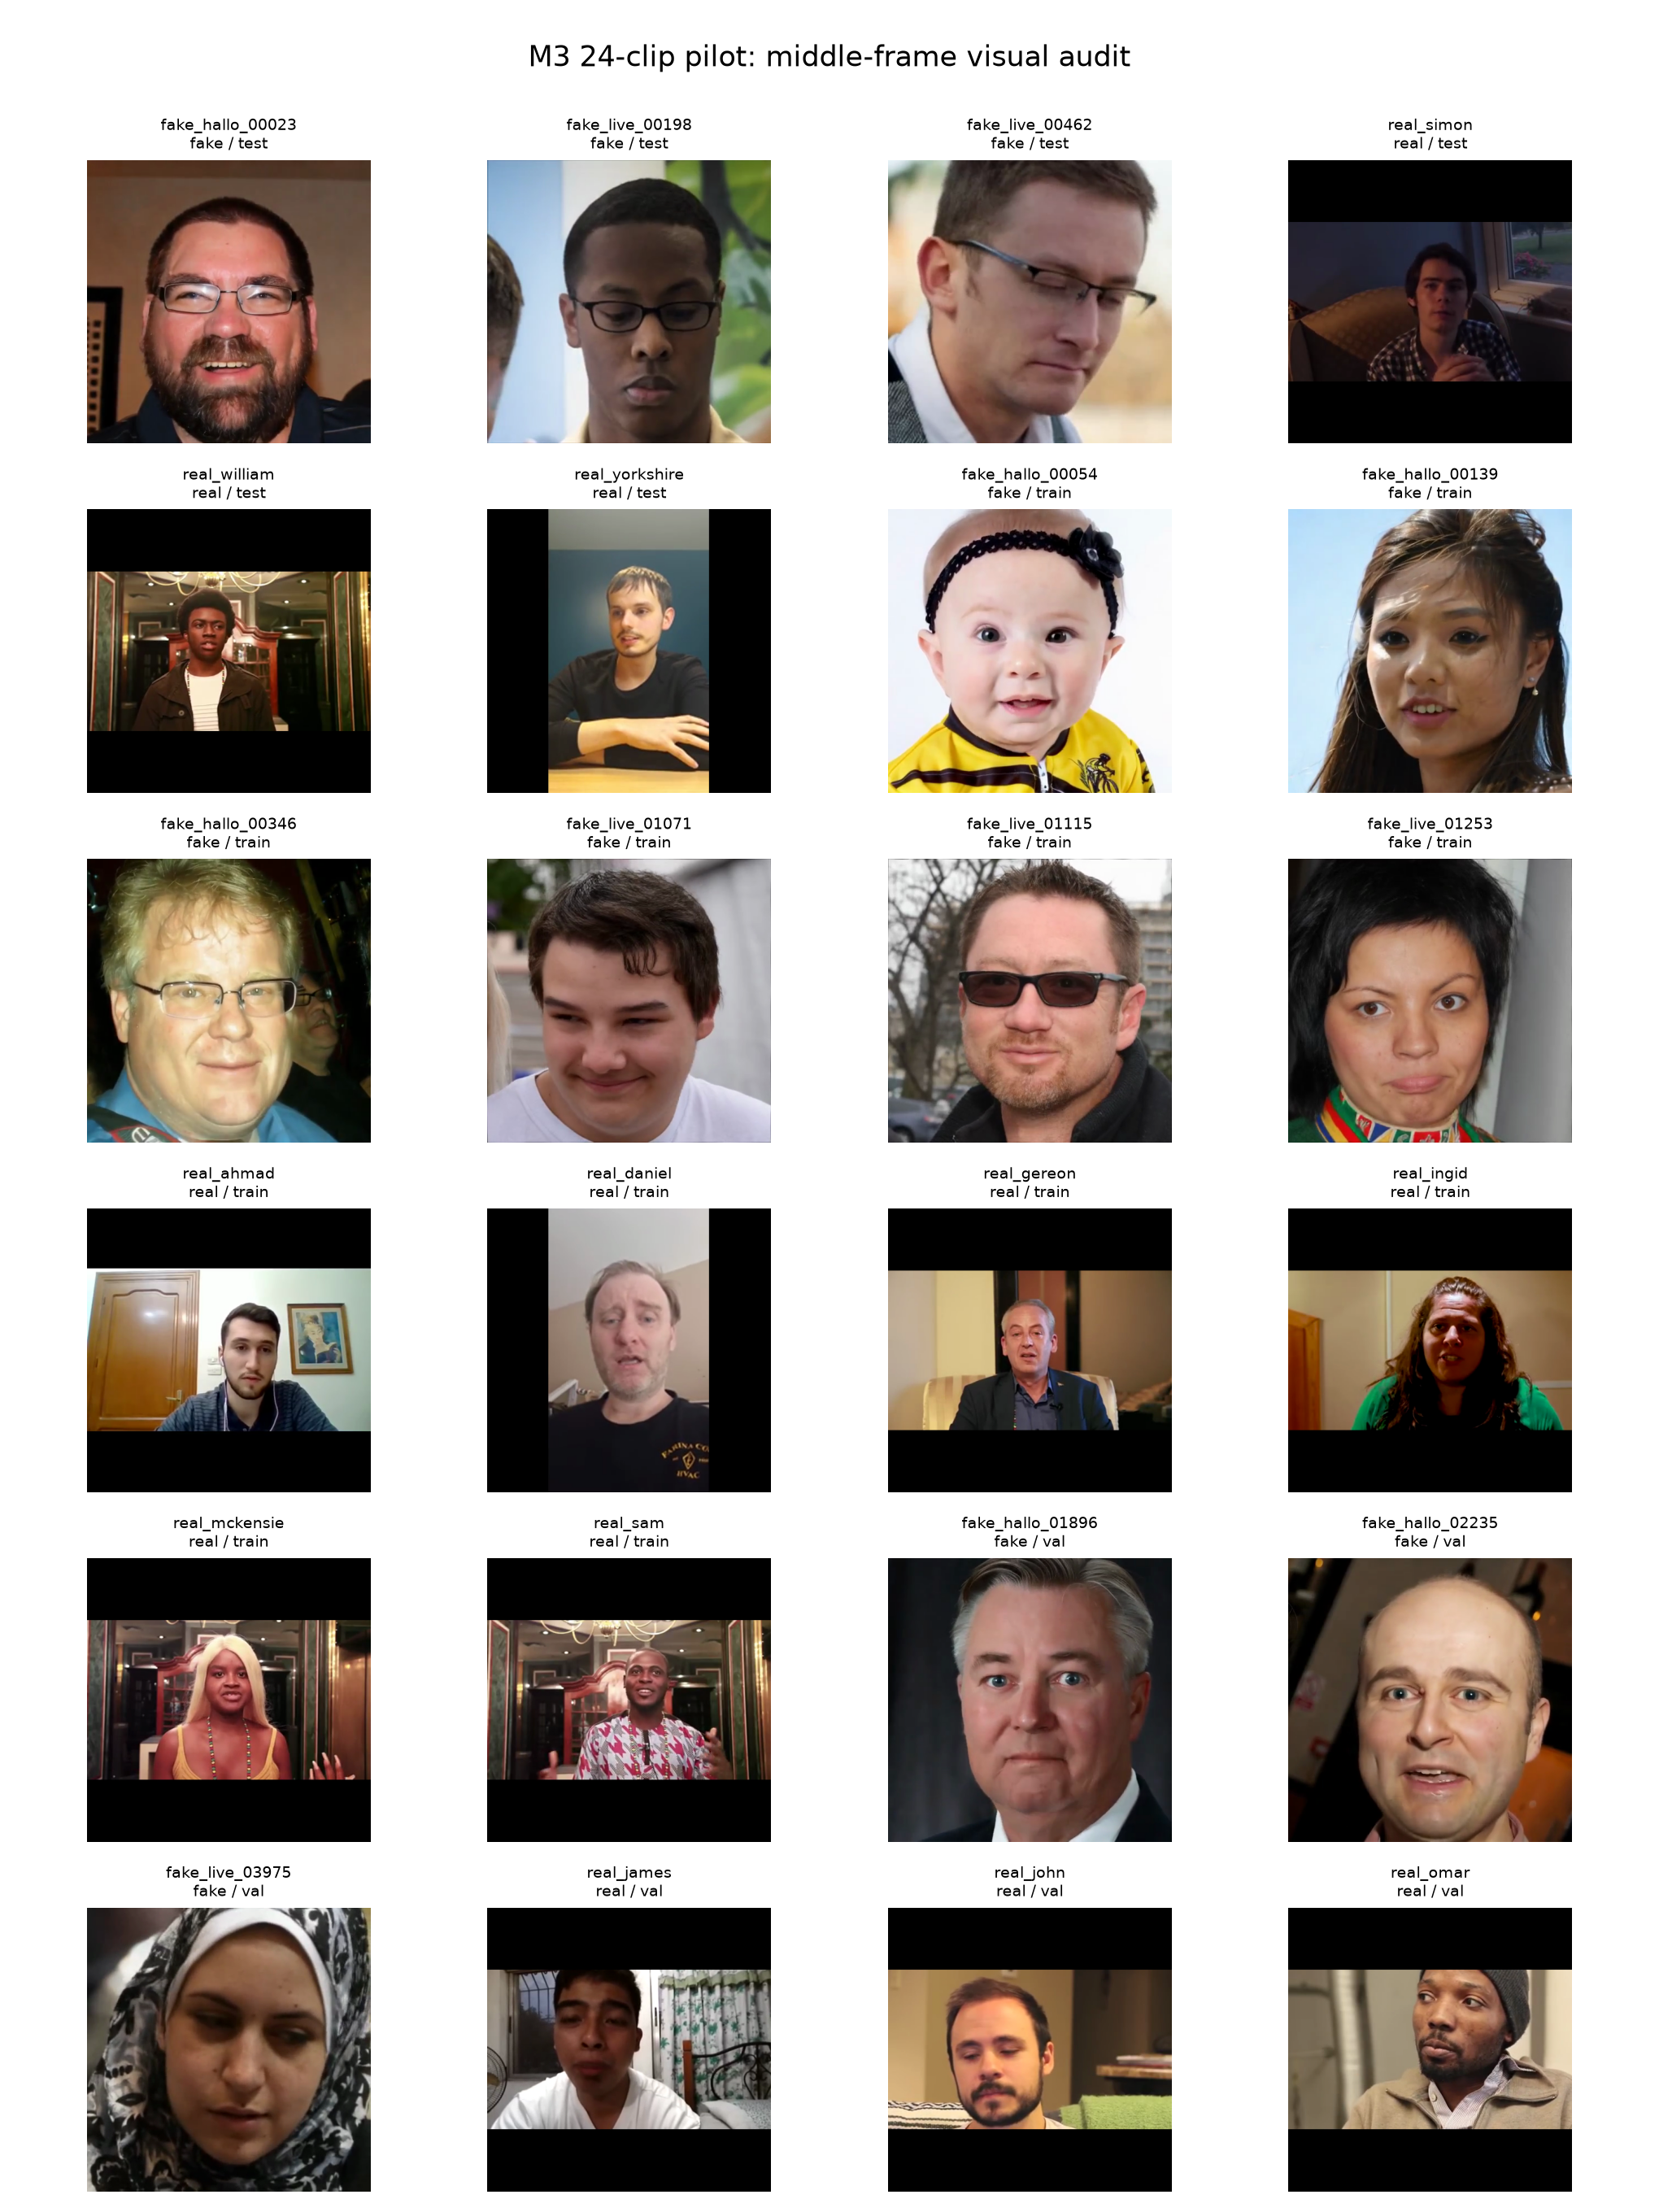

In [4]:
processed = ROOT / "data/processed/m3_pilot"
if len(list(processed.glob("*.mp4"))) != 24:
    subprocess.run([sys.executable, "scripts/download_m3_pilot.py"], cwd=ROOT, check=True)
else:
    print("Reusing 24 hash-recorded public pilot clips from the execution cache.")
subprocess.run([sys.executable, "scripts/audit_m3_pilot.py"], cwd=ROOT, check=True)
import pandas as pd
from IPython.display import display, Image
manifest = pd.read_csv(ROOT / "data/m3_pilot_manifest.csv")
display(manifest.groupby(["split", "label"]).size().rename("clips").reset_index())
display(pd.read_csv(ROOT / "outputs/m3_work/pilot_qc/metadata_qc.csv").head())
display(Image(filename=str(ROOT / "outputs/m3_work/pilot_qc/contact_sheet.png")))


## 4. Mouth landmarks and phonetic context

MediaPipe extracts normalized lip geometry and derivatives. Whisper tiny.en supplies word timestamps; CMUdict supplies English pronunciations. Uniform phone placement within each word creates a weak proxy, not forced-alignment ground truth. We compare both models on the same 12 train, 6 validation and 6 test clips.

In [5]:
from s2f.demo import MODEL_URL, download
def run_checked(command):
    completed = subprocess.run(command, cwd=ROOT, check=False, text=True, capture_output=True,
                               env=dict(os.environ, PYTHONPATH=str(ROOT / "src")))
    if completed.returncode:
        print(completed.stdout)
        print(completed.stderr)
        completed.check_returncode()
    if completed.stdout.strip():
        print(completed.stdout.strip())

model = download(MODEL_URL, ROOT / "models/face_landmarker.task")
features = ROOT / "outputs/m3_work/pilot_features"
if not (features / "qc.csv").exists():
    run_checked([sys.executable, "-m", "s2f.cli", "extract-manifest", "data/m3_pilot_manifest.csv",
                 "--root", ".", "--out", "outputs/m3_work/pilot_features",
                 "--model", "models/face_landmarker.task"])
qc = pd.read_csv(features / "qc.csv")
display(qc[["clip_id", "sampled_frames", "coverage", "status"]])
assert len(qc) == 24 and qc.coverage.min() >= 0.8
run_checked([sys.executable, "scripts/build_weak_phoneme_intervals.py"])
run_checked([sys.executable, "-m", "s2f.cli", "evaluate", "data/m3_pilot_aligned_manifest.csv",
             "--features", "outputs/m3_work/pilot_features/features", "--intervals", "data/m3_pilot_intervals.csv",
             "--root", ".", "--out", "outputs/m3_work/pilot_eval_context", "--protocol", "speaker"])
run_checked([sys.executable, "scripts/summarize_lip_pilot.py"])


,clip_id,sampled_frames,coverage,status
0,fake_hallo_00023,298,1.0,ok
1,fake_live_00198,250,1.0,ok
2,fake_live_00462,273,1.0,ok
3,real_simon,300,1.0,ok
4,real_william,300,1.0,ok
5,real_yorkshire,300,1.0,ok
6,fake_hallo_00054,277,1.0,ok
7,fake_hallo_00139,288,1.0,ok
8,fake_hallo_00346,292,1.0,ok
9,fake_live_01071,294,1.0,ok


transcribe fake_hallo_00023
transcribe fake_live_00198
transcribe fake_live_00462
transcribe real_simon
transcribe real_william
transcribe real_yorkshire
transcribe fake_hallo_00054
transcribe fake_hallo_00139
transcribe fake_hallo_00346
transcribe fake_live_01071
transcribe fake_live_01115
transcribe fake_live_01253
transcribe real_ahmad
transcribe real_daniel
transcribe real_gereon
transcribe real_ingid
transcribe real_mckensie
transcribe real_sam
transcribe fake_hallo_01896
transcribe fake_hallo_02235
transcribe fake_live_03975
transcribe real_james
transcribe real_john
transcribe real_omar
           previous_phoneme  central_phoneme  next_phoneme
affricate               0.0              0.0             1
fricative               1.0              0.0             4
glide                   3.0              0.0             1
liquid                  3.0              0.0             2
nasal                   5.0              0.0             4
stop                   11.0              0.0 

n  macro_f1    auroc  threshold        model split protocol  seed evidence  n_train  n_train_speakers  n_eval_speakers
 6  0.828571 1.000000        0.5 context_free   val  speaker  5230    pilot       12                12                6
 6  0.485714 0.666667        0.5 context_free  test  speaker  5230    pilot       12                12                6
 6  0.142857 0.000000        0.5      context   val  speaker  5230    pilot       12                12                6
 6  0.485714 0.555556        0.5      context  test  speaker  5230    pilot       12                12                6


model  n_test  macro_f1  macro_f1_ci_low  macro_f1_ci_high    auroc  auroc_ci_low  auroc_ci_high
context_free       6  0.485714         0.142857          0.828571 0.666667      0.108333            1.0
weak_context       6  0.485714         0.142857          0.828571 0.555556      0.000000            1.0
{
  "weak_context_minus_context_free": {
    "macro_f1": 0.0,
    "macro_f1_bootstrap_95_ci": [
      0.0,
      0.0
    ],
    "auroc": -0.11111111111111116,
    "auroc_bootstrap_95_ci": [
      -0.44444444444444453,
      0.0
    ]
  },
  "bootstrap": "5000 paired stratified resamples; fixed threshold 0.5",
  "interpretation": "No evidence that weak proxy context improves the six-clip held-out pilot.",
  "limitations": [
    "Only six held-out clips (three real, three fake).",
    "Real and fake clips come from different source collections, so domain cues may confound the pilot.",
    "Whisper word timestamps plus uniform CMUdict phone placement are weak proxies, not forced alignment.

,n,macro_f1,auroc,threshold,model,split,protocol,seed,evidence,n_train,n_train_speakers,n_eval_speakers
0,6,0.828571,1.000000,0.5,context_free,val,speaker,5230,pilot,12,12,6
1,6,0.485714,0.666667,0.5,context_free,test,speaker,5230,pilot,12,12,6
2,6,0.142857,0.000000,0.5,context,val,speaker,5230,pilot,12,12,6
3,6,0.485714,0.555556,0.5,context,test,speaker,5230,pilot,12,12,6


,clip_id,label,generator,context_free_probability,context_probability,context_free_error,context_error
0,fake_hallo_00023,fake,Hallo,0.425988,0.008141,True,True
1,fake_live_00198,fake,LivePortrait,0.121255,0.035770,True,True
2,fake_live_00462,fake,LivePortrait,0.936964,0.993772,False,False
3,real_simon,real,none,0.771709,0.872283,True,True
4,real_william,real,none,0.029608,0.000823,False,False
5,real_yorkshire,real,none,0.415490,0.179836,False,False


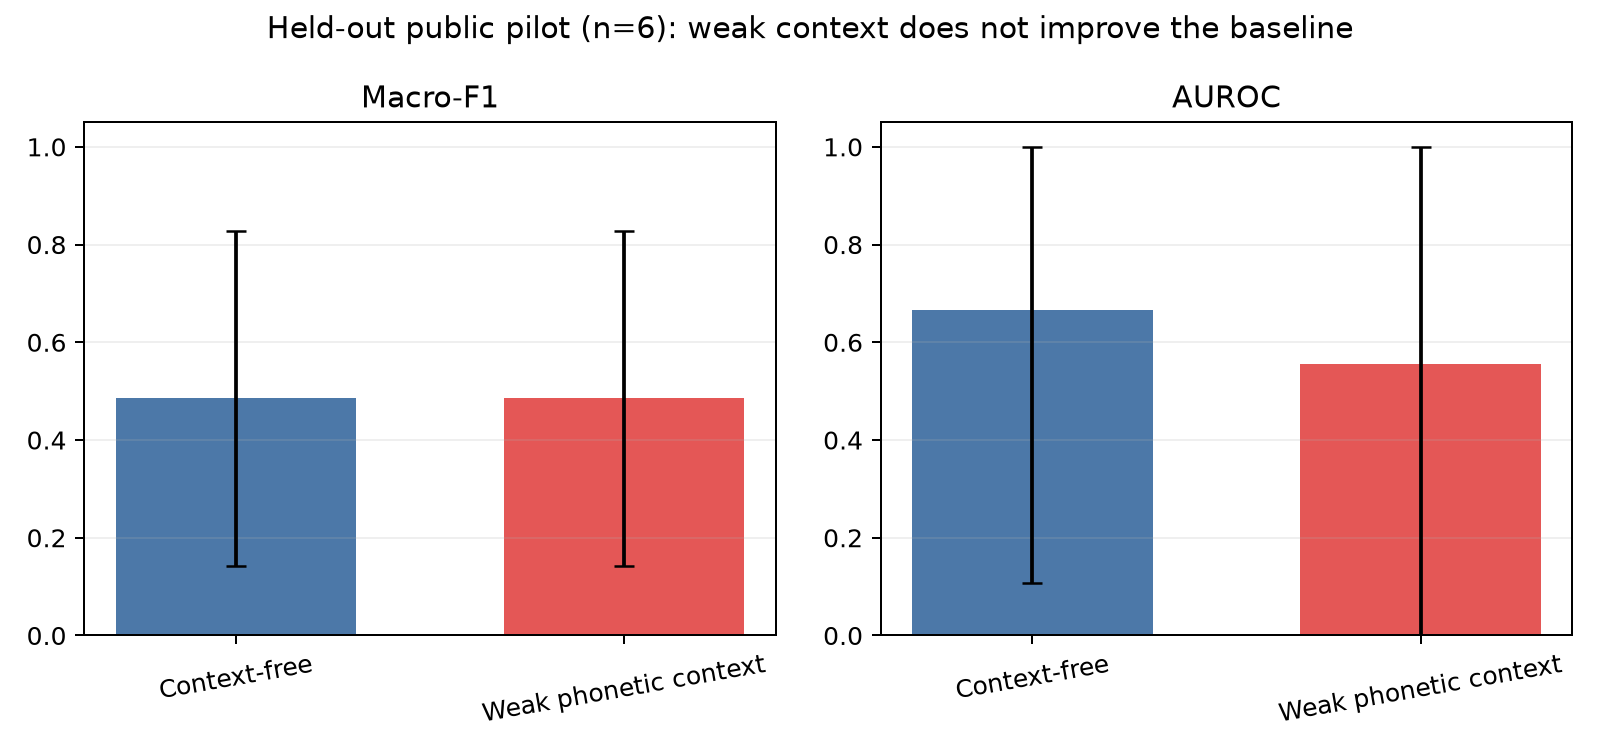

Result: the weak context proxy did not improve the six-clip held-out pilot.


In [6]:
results = pd.read_csv(ROOT / "outputs/m3_work/pilot_eval_context/metrics/results.csv")
display(results)
display(pd.read_csv(ROOT / "outputs/m3_work/lip_pilot_summary/held_out_predictions_and_failures.csv"))
display(Image(filename=str(ROOT / "outputs/m3_work/lip_pilot_summary/lip_pilot_results.png")))
print("Result: the weak context proxy did not improve the six-clip held-out pilot.")


## 5. Dark.Mimic paired chromatic audit

Dark.Mimic supplied one aligned control and A=1 modified video. We measure modified-minus-control RGB differences and spectral energy near the peer-reported 1.2 Hz setting. A neutral re-encode tests codec effects. The raw peer files stay outside the public repository. The aggregate below identifies them by SHA256. This paired forensic measurement does not estimate physiology and does not classify real versus fake.

In [7]:
provenance = json.loads((ROOT / "artifacts/m3_results/peer_pair_provenance.json").read_text())
print(json.dumps(provenance, indent=2))
pair = pd.read_csv(ROOT / "artifacts/m3_results/attack_vs_neutral.csv")
robust = pd.read_csv(ROOT / "artifacts/m3_results/robustness_summary.csv")
display(pair[pair.roi.eq("global")])
display(robust)

import matplotlib.pyplot as plt
red = robust[robust.channel.eq("red")].set_index("condition").loc[["original", "h264_crf35", "resize_256", "fps_15"]]
x = range(len(red))
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar([i - .18 for i in x], red.attack, .36, label="Dark.Mimic A=1")
ax.bar([i + .18 for i in x], red.neutral, .36, label="Neutral re-encode")
ax.set_xticks(list(x), ["Original", "H.264 CRF 35", "256×224", "15 FPS"])
ax.set_ylim(0, 1); ax.set_ylabel("Red energy fraction near 1.2 Hz")
ax.set_title("Periodic chromatic trace under post-processing"); ax.legend(); ax.grid(axis="y", alpha=.2)
plt.show()


{
  "scope": "Dark.Mimic peer-supplied pair used for the M3 paired forensic audit",
  "redistribution": "raw videos excluded from the public repository",
  "files": [
    {
      "role": "control",
      "original_name": "person01_fake01_control.mp4",
      "sha256": "05b771eee52dc629904f9e0b40f52d715d8c42d2535576c2f135974f1d302edd"
    },
    {
      "role": "Dark.Mimic A=1 modification",
      "original_name": "person01_fake01_attacked_A1.mp4",
      "sha256": "55cde2f07cc3f95c4f5c35f505e229d19e5f599567e434caa89fd18b8066123a"
    },
    {
      "role": "team-created neutral re-encode control",
      "original_name": "person01_fake01_control_neutral_reencode.mp4",
      "sha256": "88024d5372605531d58241a6c8418a76aa2543e06273aaeb092ab71cddb265da"
    }
  ],
  "claim_boundary": "One aligned pair supports a descriptive manipulation audit only. It does not estimate physiology or establish population-level real/fake detection."
}


,roi,channel,peak_hz_attack,peak_to_median_ratio_attack,target_band_energy_fraction_attack,peak_hz_neutral,peak_to_median_ratio_neutral,target_band_energy_fraction_neutral,peak_to_median_ratio_ratio,target_band_energy_fraction_ratio
0,global,red,1.15894,1070.884740,0.945692,0.827815,9.826426,0.204362,108.980085,4.627539
1,global,green,1.15894,929.925131,0.938801,1.655629,8.653545,0.110759,107.461757,8.476087
2,global,blue,1.15894,127.522189,0.660276,2.069536,17.976389,0.003978,7.093871,165.975571


,condition,channel,attack,neutral,attack_to_neutral_ratio
0,fps_15,blue,0.387792,0.056447,6.870083
1,fps_15,green,0.910952,0.030366,29.998600
2,fps_15,red,0.873277,0.041859,20.862371
3,h264_crf35,blue,0.291708,0.033487,8.711205
4,h264_crf35,green,0.732991,0.201588,3.636082
5,h264_crf35,red,0.367235,0.043466,8.448732
6,original,blue,0.660276,0.003978,165.975571
7,original,green,0.938801,0.110759,8.476087
8,original,red,0.945692,0.204362,4.627539
9,resize_256,blue,0.196731,0.045829,4.292720


/var/folders/n0/ffygq5jx4cs5mymfgm1fqs_r0000gn/T/ipykernel_43926/982708334.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Optional private-pair rerun

Team members can place the three verified MP4 files under `data/private/dark_mimic/` and set `RUN_PRIVATE_PAIR=True`. The public notebook skips this cell rather than downloading or fabricating private data.

In [8]:
RUN_PRIVATE_PAIR = False
private = ROOT / "data/private/dark_mimic"
required_private = [private / "person01_fake01_control.mp4",
                    private / "person01_fake01_attacked_A1.mp4",
                    private / "person01_fake01_control_neutral_reencode.mp4"]
if RUN_PRIVATE_PAIR:
    if not all(path.exists() for path in required_private):
        raise FileNotFoundError("Place the three hash-verified private MP4 files in data/private/dark_mimic")
    subprocess.run([sys.executable, "scripts/run_chromatic_robustness.py"], cwd=ROOT, check=True,
                   env=dict(os.environ, PYTHONPATH=str(ROOT / "src")))
else:
    print("Private-pair rerun skipped. Displayed aggregate results remain linked to SHA256 provenance.")


Private-pair rerun skipped. Displayed aggregate results remain linked to SHA256 provenance.


## 6. Conclusions and claim boundaries

1. All 24 public clips passed landmark coverage, but the context-free test result remained small and uncertain (macro-F1 0.486; AUROC 0.667; n=6).
2. The weak phonetic-context proxy did not improve the held-out result (macro-F1 0.486; AUROC 0.556). This negative result points to forced alignment, matched real/fake sources and more clips as the next research step.
3. In the single peer pair, periodic colour energy near 1.2 Hz remained higher than the neutral control after H.264 CRF 35, resizing and 15 FPS. This supports a paired manipulation audit, not a general detector.

The integrated Light defense keeps both channels separate: lip dynamics test S2F generation artefacts, while chromatic forensics test traces introduced by the attempted rPPG evasion. We do not tune fusion on one peer pair.